# G11

# 1.0 Table of Contents
1. [2.1 Import Libraries](#2.1-Import-Libraries)
2. [2.2 Data Exploration and Visualization](#2.2-Data-Exploration-and-Visualization)
3. [2.3 Data Preprocessing](#2.3-Data-Preprocessing)
4. [2.4: Model Selection](#2.4:-Model-Selection)
   1. [Model 1: k-Nearest Neighbor (kNN)](#Model-1:-k-Nearest-Neighbor-(kNN))
   2. [Model 2: Support Vector Classifier (SVC)](#Model-2:-Support-Vector-Classifier (SVC))
   3. [Model 3: Logistic Regression](#Model-3:-Logistic-Regression)
   4. [Model 4: Random Forest](#Model-4:-Random-Forest)
5. [2.5 Model Fining and Tuning](#2.5-Model-Fining-and-Tuning)
   1. [Model 1: k-Nearest Neighbor (kNN)](#Model-1:-k-Nearest-Neighbor-(kNN))
   2. [Model 2: Support Vector Classifier (SVC)](#Model-2:-Support-Vector-Classifier (SVC))
   3. [Model 3: Logistic Regression](#Model-3:-Logistic-Regression)
   4. [Model 4: Random Forest](#Model-4:-Random-Forest)
6. [3.0 Model Comparison](#3.0-Model-Comparison)
<br><br>

# 2.1 Import Libraries

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Split dataset
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize,LabelEncoder
from sklearn.model_selection import cross_val_score, cross_val_predict

# Model Training and Tuning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import make_scorer


In [194]:
# Load dataset to variable "cardio"
cardio = pd.read_csv("dataset.csv")

# 2.2 Data Exploration and Visualization

In [195]:
# Show the first 10 items in dataset
cardio.head(10)

,Gender,Age,Height(cm),Weight(kg),Family_history,Alcohol,Junk_food,Vege_day,Meals_day,Snack,Smoking,Water_intake(L),Transportation,Exercise,TV,Income,Discipline,Cardiovascular_risk(y)
0,Female,42,172.2,82.9,no,low,yes,3,3,Sometimes,no,2.72,car,3,rare,2081,no,medium
1,Female,19,175.3,80.0,yes,none,yes,2,1,Sometimes,no,2.65,bus,3,moderate,5551,no,medium
2,Female,43,158.3,81.9,yes,none,yes,3,1,Sometimes,no,1.89,car,1,rare,14046,no,high
3,Female,23,165.0,70.0,yes,low,no,2,1,Sometimes,no,2.00,bus,0,rare,9451,no,medium
4,Male,23,169.0,75.0,yes,low,yes,3,3,Sometimes,no,2.82,bus,1,often,17857,no,medium
5,Male,23,172.0,82.0,yes,low,yes,2,1,Sometimes,no,1.00,bus,1,moderate,3114,no,medium
6,Female,21,172.0,133.9,yes,low,yes,3,3,Sometimes,no,2.42,bus,2,moderate,8011,no,high
7,Male,21,172.5,82.3,yes,low,yes,2,2,Sometimes,no,2.00,bus,2,moderate,5838,no,medium
8,Female,19,165.0,82.0,yes,none,yes,3,3,Sometimes,no,1.00,bus,0,moderate,10029,no,high
9,Male,22,187.1,89.3,yes,low,yes,2,3,Sometimes,no,1.08,bus,0,moderate,13784,no,medium


In [196]:
# Show the quick description all attributes in the DataFrame cardio

cardio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  2100 non-null   object 
 1   Age                     2100 non-null   int64  
 2   Height(cm)              2100 non-null   float64
 3   Weight(kg)              2100 non-null   float64
 4   Family_history          2100 non-null   object 
 5   Alcohol                 2100 non-null   object 
 6   Junk_food               2100 non-null   object 
 7   Vege_day                2100 non-null   int64  
 8   Meals_day               2100 non-null   int64  
 9   Snack                   2100 non-null   object 
 10  Smoking                 2100 non-null   object 
 11  Water_intake(L)         2100 non-null   float64
 12  Transportation          2100 non-null   object 
 13  Exercise                2100 non-null   int64  
 14  TV                      2100 non-null   

In [197]:
# Identifying categorical features by checking data types
cat_features = cardio.select_dtypes(include = ['object', 'category']).columns

# List the exact attributes for each categorical feature
for feature in cat_features:
    print("{}: {}".format(feature, cardio[feature].unique()))

Gender: ['Female' 'Male']
Family_history: ['no' 'yes']
Alcohol: ['low' 'none' 'medium' 'high']
Junk_food: ['yes' 'no']
Snack: ['Sometimes' 'Always' 'Frequently' 'No']
Smoking: ['no' 'yes']
Transportation: ['car' 'bus' 'walk' 'motorcycle' 'bicycle']
TV: ['rare' 'moderate' 'often']
Discipline: ['no' 'yes']
Cardiovascular_risk(y): ['medium' 'high' 'low']


In [198]:
#Show all the numerical attributes in cardio
cardio.describe()

,Age,Height(cm),Weight(kg),Vege_day,Meals_day,Water_intake(L),Exercise,Income
count,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000
mean,24.302381,170.148286,86.561571,2.423333,2.687143,2.007429,1.006190,9432.386190
std,6.342270,9.340941,26.192242,0.584318,0.810088,0.613122,0.894885,5002.350673
min,14.000000,145.000000,39.000000,1.000000,1.000000,1.000000,0.000000,1000.000000
25%,20.000000,163.000000,65.400000,2.000000,3.000000,1.577500,0.000000,4994.500000
50%,23.000000,170.000000,83.000000,2.000000,3.000000,2.000000,1.000000,9226.500000
75%,26.000000,176.800000,107.250000,3.000000,3.000000,2.480000,2.000000,13841.750000
max,61.000000,198.000000,173.000000,3.000000,4.000000,3.000000,3.000000,18000.000000


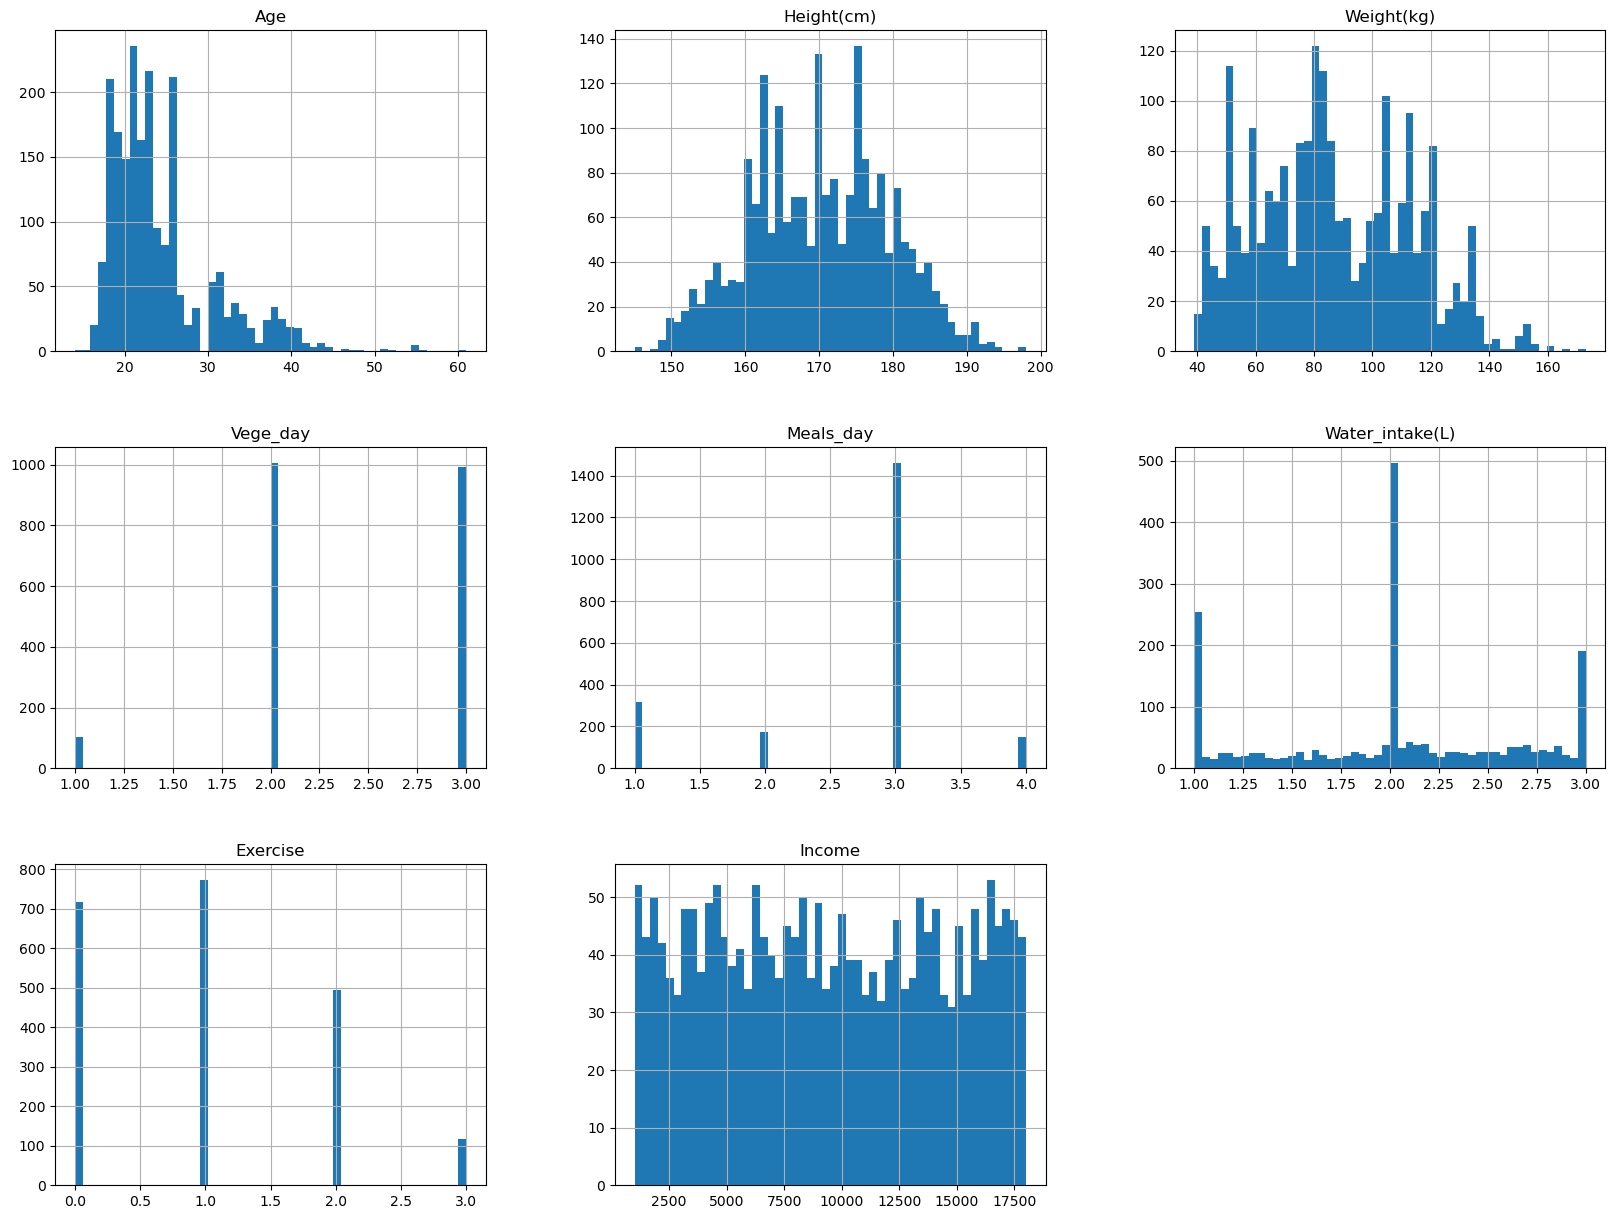

In [199]:
# Plot the histogram of each numerical attribute
cardio.hist(bins=50, figsize=(20,15))
plt.show()

C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

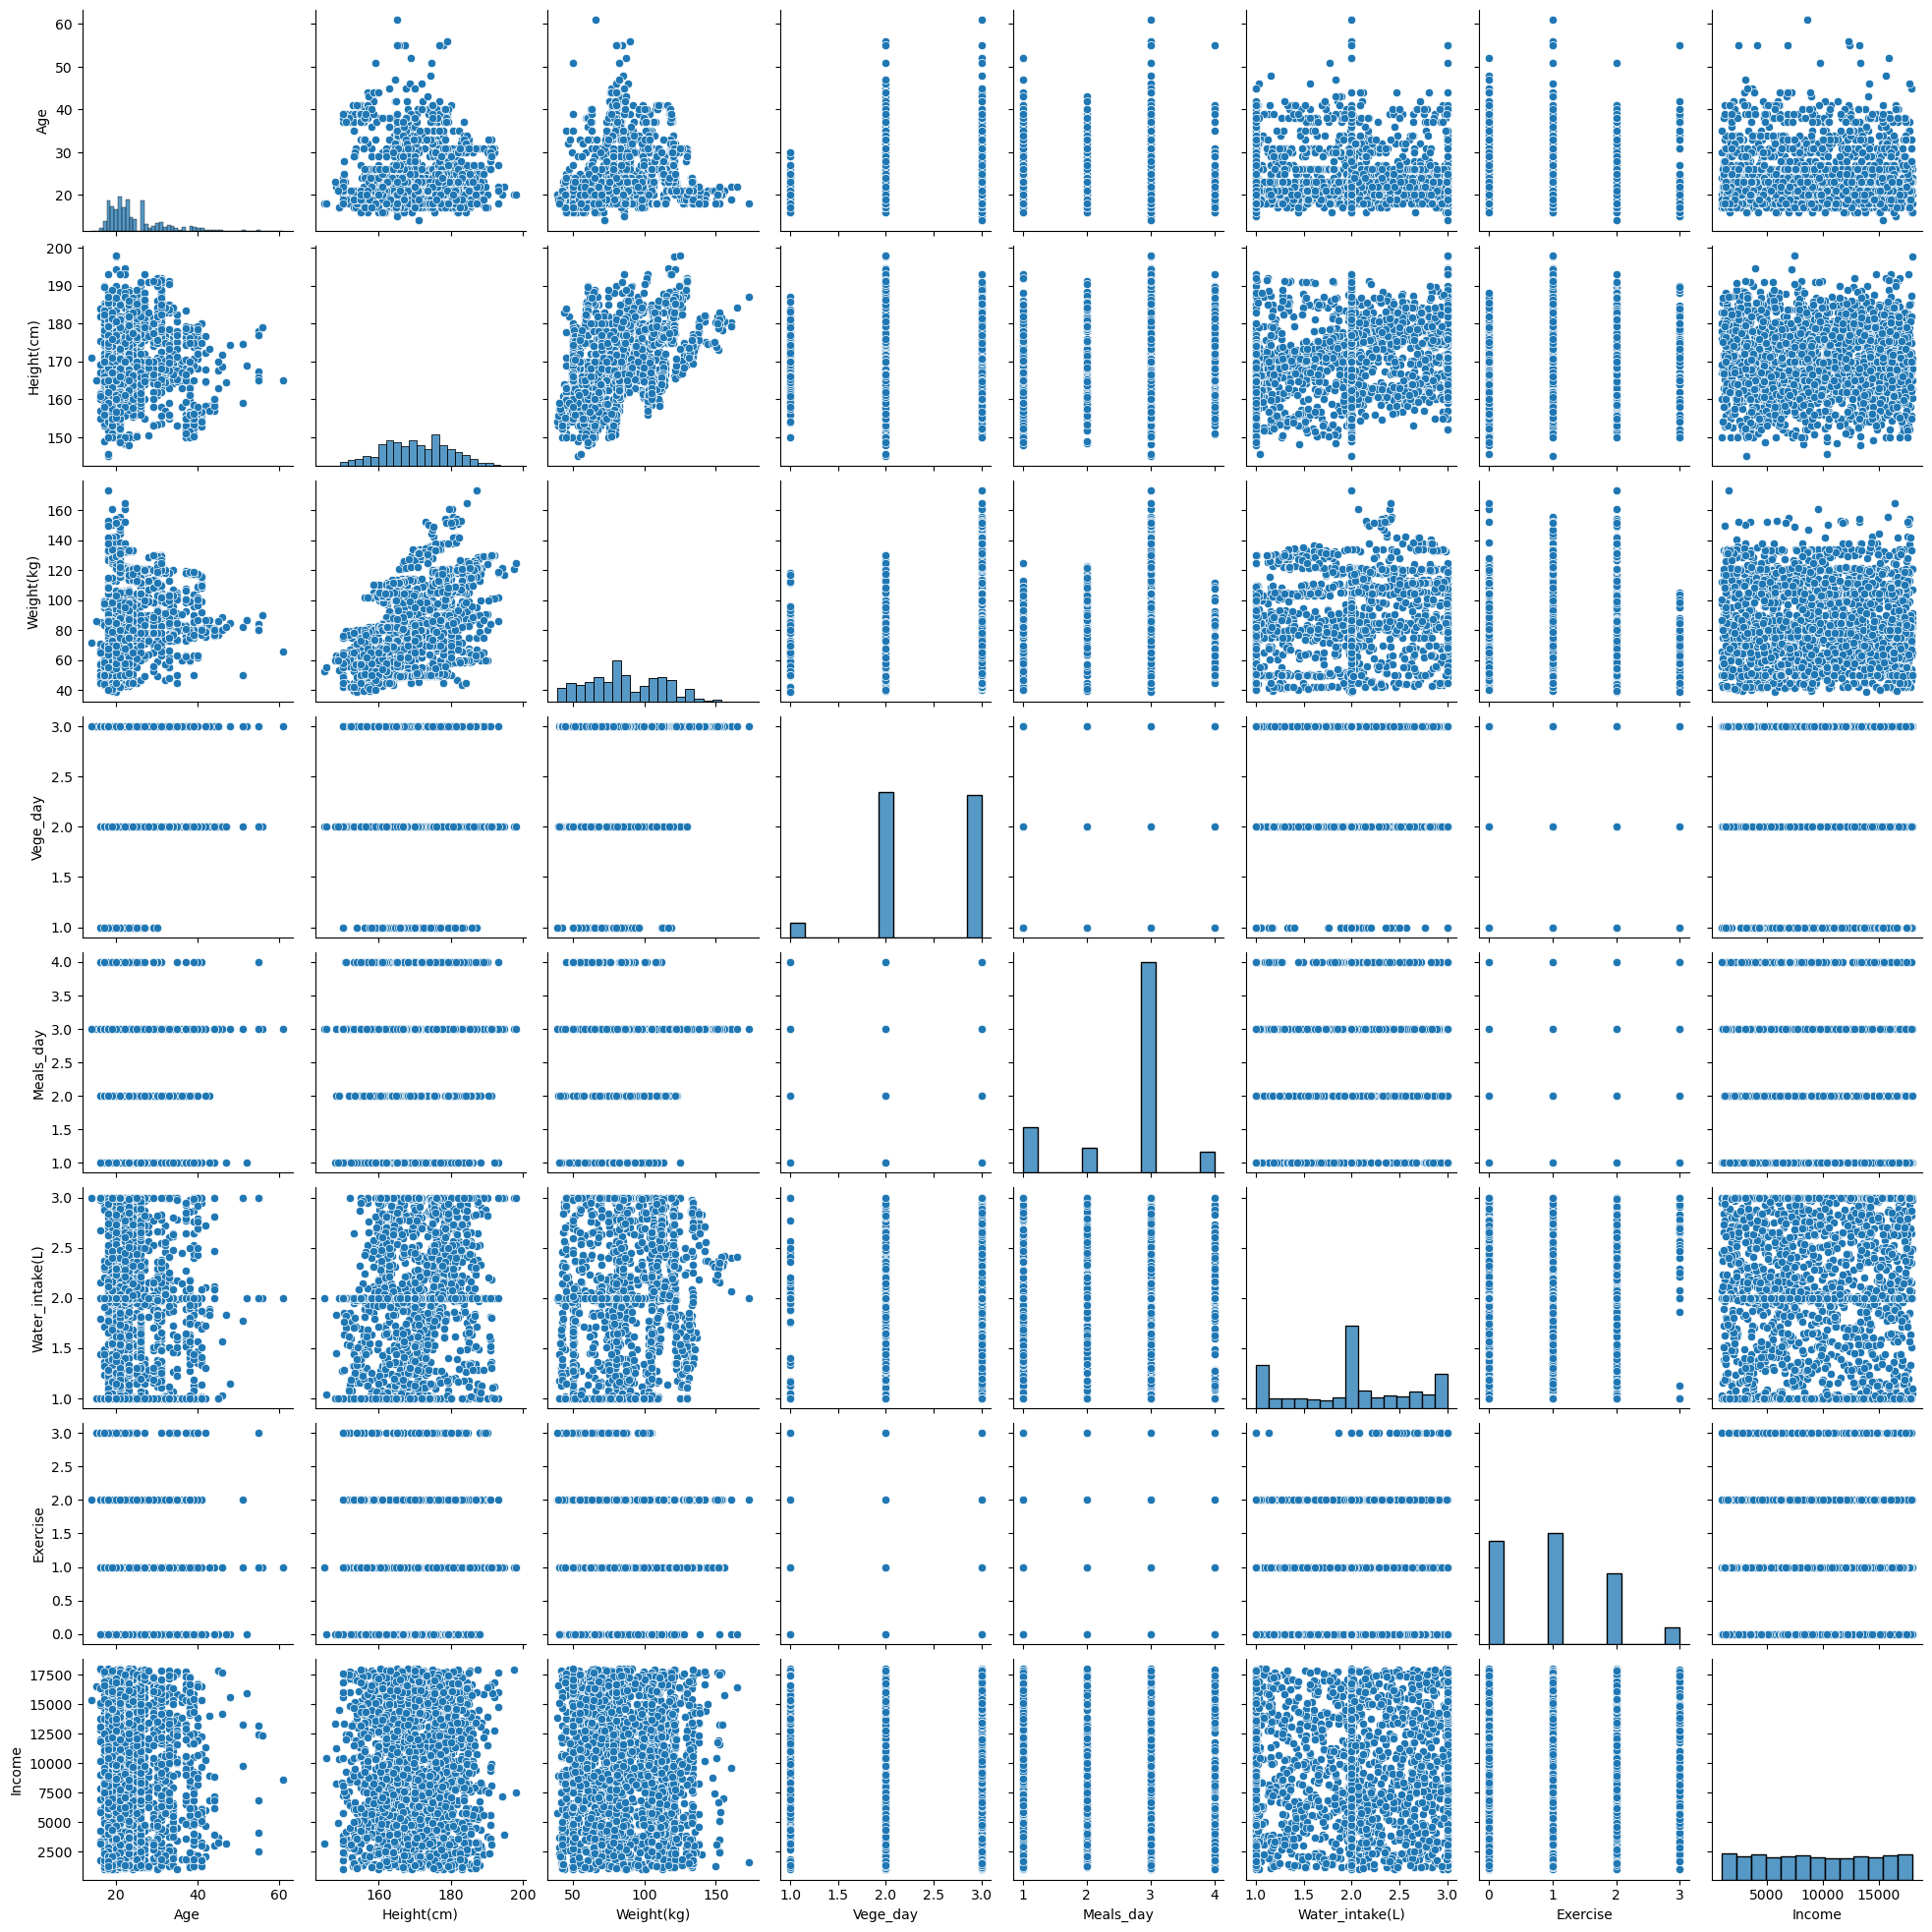

In [200]:
# Check missing value of all features
cardio.isnull().sum()

# Pairplot of numerical features
sns.pairplot(cardio[['Age', 'Height(cm)', 'Weight(kg)', 'Vege_day', 'Meals_day', 'Water_intake(L)', 'Exercise', 'Income']])
plt.show()

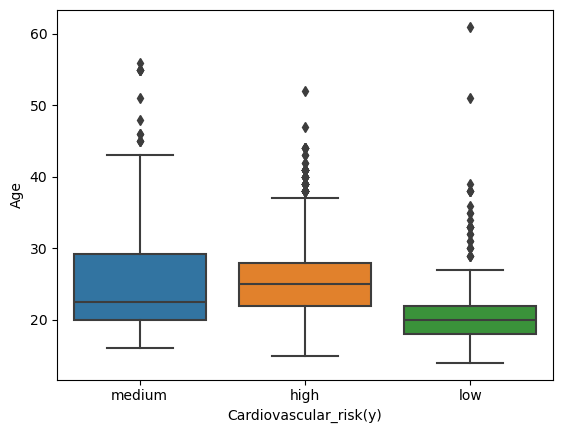

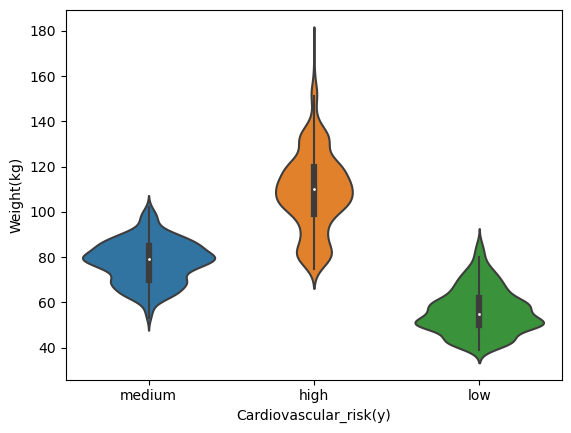

In [201]:
# Boxplot to show distribution of Age across different categories of Cardiovascular_risk
sns.boxplot(x='Cardiovascular_risk(y)', y='Age', data=cardio)
plt.show()

# Violin plot for Weight and Cardiovascular Risk
sns.violinplot(x='Cardiovascular_risk(y)', y='Weight(kg)', data=cardio)
plt.show()

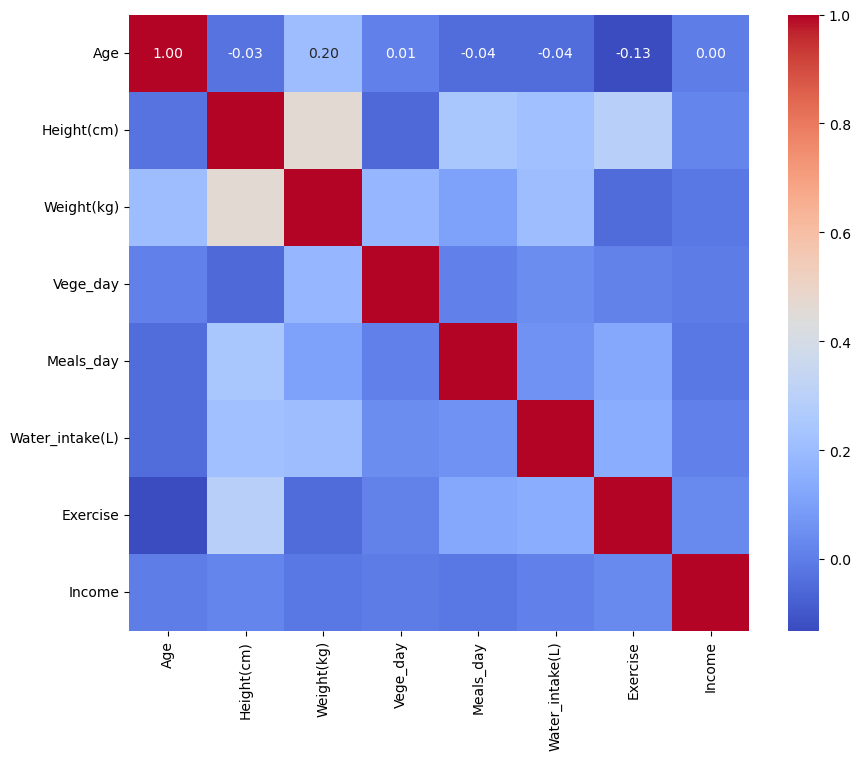

In [202]:
# Calculate correlation matrix for numerical features
corr_matrix = cardio[['Age', 'Height(cm)', 'Weight(kg)', 'Vege_day', 'Meals_day', 'Water_intake(L)', 'Exercise', 'Income']].corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

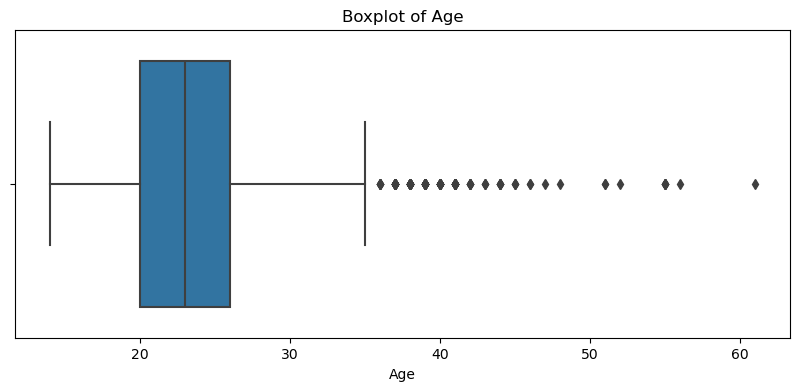

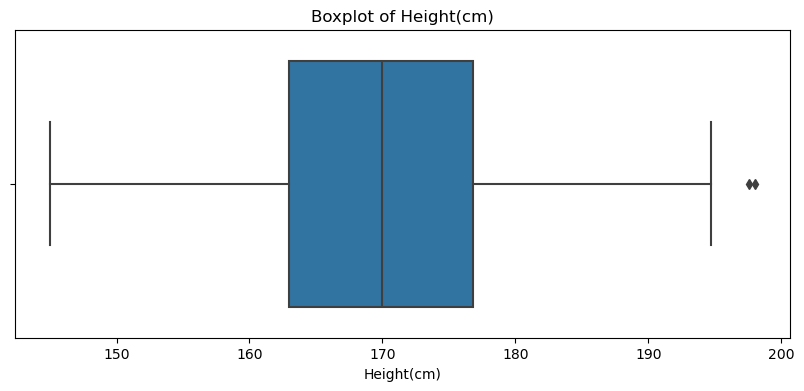

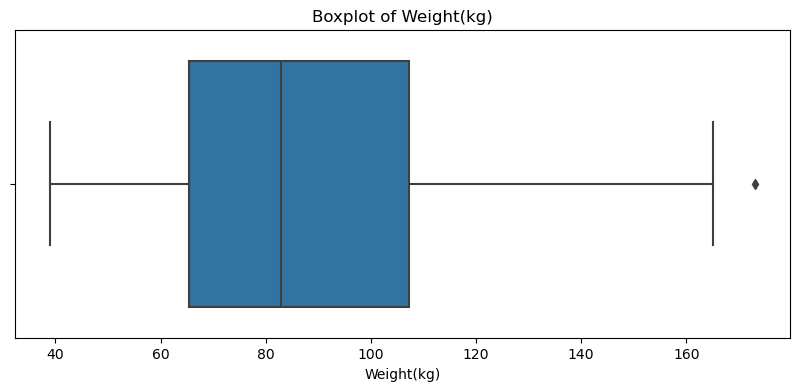

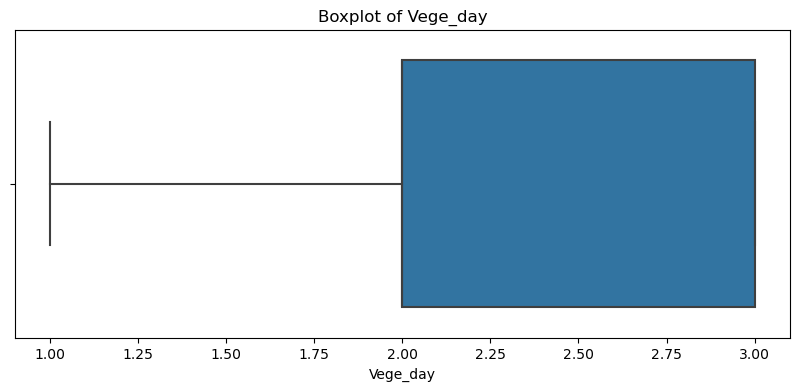

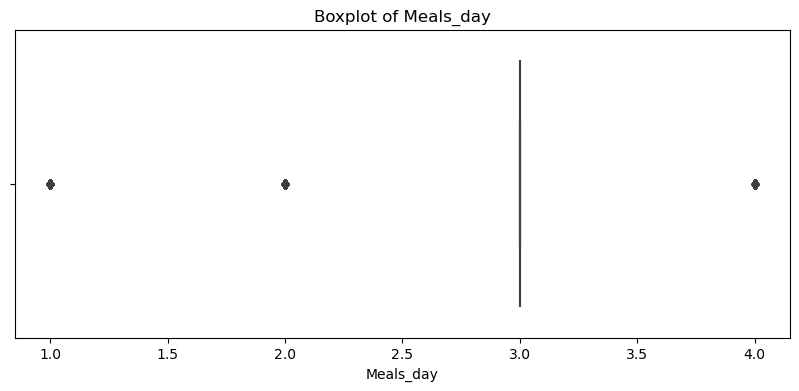

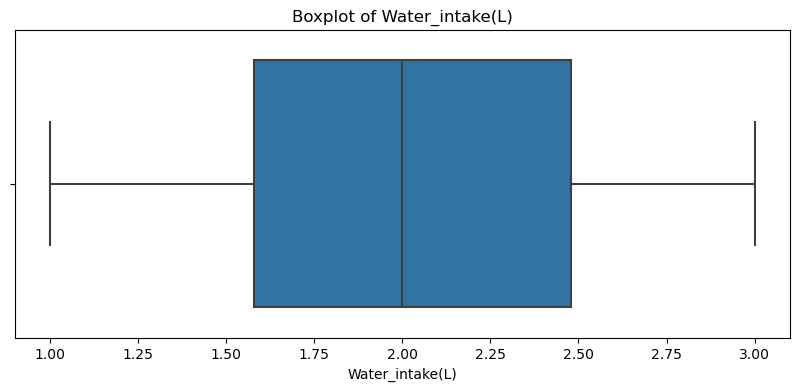

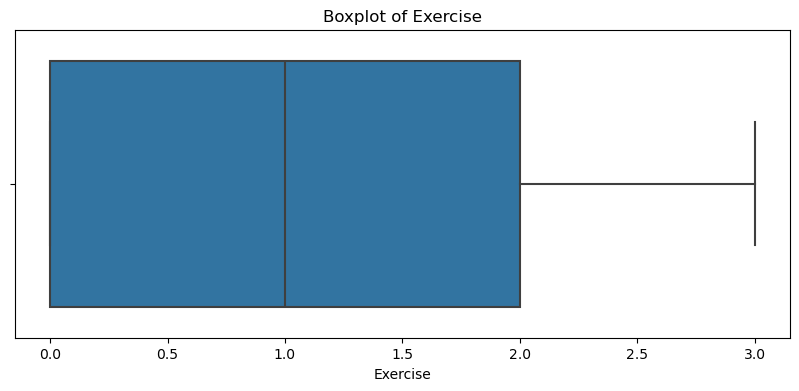

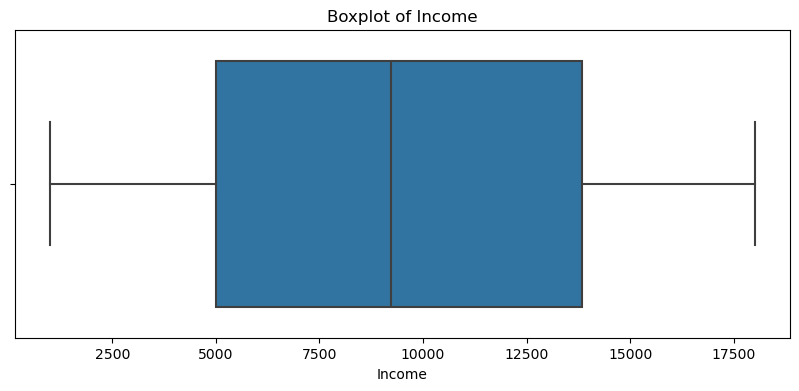

In [203]:
for feature in ['Age', 'Height(cm)', 'Weight(kg)', 'Vege_day', 'Meals_day', 'Water_intake(L)', 'Exercise', 'Income']:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=cardio, x=feature)
    plt.title(f'Boxplot of {feature}')
    plt.show()

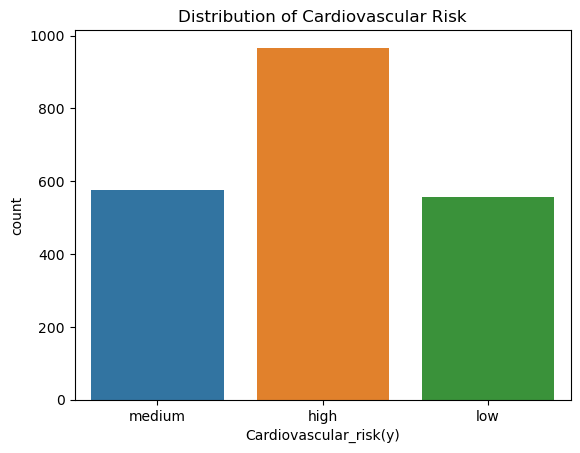

In [204]:
# Countplot to visualize target variable distribution
sns.countplot(x='Cardiovascular_risk(y)', data=cardio)
plt.title('Distribution of Cardiovascular Risk')
plt.show()

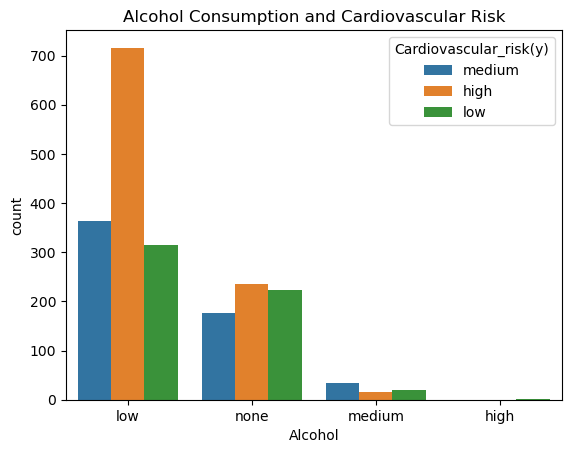

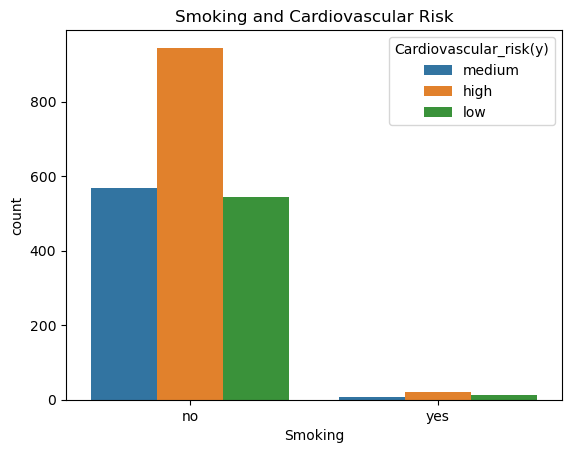

In [205]:
# Countplot to check relationship between Alcohol consumption and Cardiovascular Risk
sns.countplot(x='Alcohol', hue='Cardiovascular_risk(y)', data=cardio)
plt.title('Alcohol Consumption and Cardiovascular Risk')
plt.show()

# Countplot for Smoking and Risk
sns.countplot(x='Smoking', hue='Cardiovascular_risk(y)', data=cardio)
plt.title('Smoking and Cardiovascular Risk')
plt.show()

# 2.3 Data Preprocessing

#### 2.3.1 Identify Missing Values

In [206]:
# Check missing value of all features
cardio.isnull().sum()

Gender                    0
Age                       0
Height(cm)                0
Weight(kg)                0
Family_history            0
Alcohol                   0
Junk_food                 0
Vege_day                  0
Meals_day                 0
Snack                     0
Smoking                   0
Water_intake(L)           0
Transportation            0
Exercise                  0
TV                        0
Income                    0
Discipline                0
Cardiovascular_risk(y)    0
dtype: int64

#### 2.3.2 Feature and Target Splitting

In [207]:
X = cardio.drop('Cardiovascular_risk(y)', axis=1)  # Drop the target column to get features
y = cardio['Cardiovascular_risk(y)']  # Target variable

#### 2.3.3 Train-Test Split

In [208]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)
print ('full set shape=', X.shape)
print ('train shape=', X_train.shape)
print ('test shape=', X_test.shape)

full set shape= (2100, 17)
train shape= (1680, 17)
test shape= (420, 17)


In [209]:
print(y_train.value_counts())

Cardiovascular_risk(y)
high      781
medium    464
low       435
Name: count, dtype: int64


#### 2.3.4 Identifying Numerical and Categorical Columns

In [210]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Split the input matrix into numerical and categorical sets
X_train_num = X_train[num_cols]
X_train_cat = X_train[cat_cols]

print('X_train_num shape:', X_train_num.shape)
print('X_train_cat shape:', X_train_cat.shape)

X_train_num shape: (1680, 8)
X_train_cat shape: (1680, 9)


#### 2.3.5 Numerical Data Standardization

In [211]:
scaler = StandardScaler(copy = False)
scaler.fit(X_train_num)       
X_train_num = scaler.transform(X_train_num)
X_test_num = scaler.transform(X_test[num_cols])
print('>>> Mean of all columns:\n', X_train_num.mean(axis=0))
print('\n>>> Standardization of all columns:\n', X_train_num.std(axis=0))

>>> Mean of all columns:
 [-1.98782789e-16  1.10440757e-15  5.64627710e-16 -1.34284118e-16
 -7.19001578e-17  3.21436000e-16  1.01506105e-16 -1.52259158e-16]

>>> Standardization of all columns:
 [1. 1. 1. 1. 1. 1. 1. 1.]


#### 2.3.6 Categorical Data Encoding

In [212]:
# Preprocessing categorical Data: One-hot encoding
oh_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
oh_encoder.fit(X_train_cat)
X_train_cat = oh_encoder.transform(X_train_cat)       # returns numpy array
X_test_cat = oh_encoder.transform(X_test[cat_cols])
print('Shape of X_train:', X_train_cat.shape, '\n')
print(X_train_cat, '\n')

Shape of X_train: (1680, 26) 

[[1. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 1. 1. 0.]
 [0. 1. 1. ... 0. 1. 0.]
 ...
 [0. 1. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 1. 1. 0.]
 [0. 1. 0. ... 1. 1. 0.]] 



In [213]:
# This code is to return the X_train as Dataframe for latest usage
X_train_cat_df = X_train.select_dtypes(exclude=[np.number])

one_hot_encoder = OneHotEncoder(drop="if_binary",sparse_output=False)
one_hot_encoder.fit(X_train_cat_df)

X_train_cat_df_tr = one_hot_encoder.transform(X_train_cat_df)
X_test_cat_df_tr = one_hot_encoder.transform(X_test[cat_cols])

X_train_cat_df_tr = X_train_cat_df_tr.astype(int)
X_test_cat_df_tr = X_test_cat_df_tr.astype(int)

feature_names = one_hot_encoder.get_feature_names_out(X_train_cat_df.columns)

# Convert the encoded array back to a DataFrame
X_train_cat_df_tr = pd.DataFrame(X_train_cat_df_tr, columns=feature_names, index=X_train.index)
X_test_cat_df_tr = pd.DataFrame(X_test_cat_df_tr, columns=feature_names, index=X_test.index)

#### 2.3.7 Finalize Training Set

In [214]:
# Finalizing the training set
X_train_tr = np.hstack([X_train_num, X_train_cat])
X_test_tr = np.hstack([X_test_num, X_test_cat])

# Convert y_train and y_test to numpy arrays
y_train = y_train.values
y_test = y_test.values

print('X_train_tr shape:', X_train_tr.shape)
print('X_test_tr shape:', X_test_tr.shape)
print('y_train shape:', y_train.shape)

X_train_tr shape: (1680, 34)
X_test_tr shape: (420, 34)
y_train shape: (1680,)


#### 2.3.8 Addressing Class Imbalance (SMOTE)

In [215]:
# Handle Imbalance using SMOTE
smote = SMOTE(random_state=30)
X_train_res, y_train_res = smote.fit_resample(X_train_tr, y_train)
print('X_train_res shape:', X_train_res.shape)
print('y_train_res shape:', y_train_res.shape)

X_test_res, y_test_res = smote.fit_resample(X_test_tr, y_test)
print('X_test_res shape:', X_test_res.shape)
print('y_test_res shape:', y_test_res.shape)

X_train_res shape: (2343, 34)
y_train_res shape: (2343,)
X_test_res shape: (558, 34)
y_test_res shape: (558,)


# 2.4: Model Selection

## Model 1: k-Nearest Neighbor (kNN)

### 2.4.1 Before Resampling

#### 1. Model Training on Train Set

In [216]:
# Initialize kNN model
knn_model = KNeighborsClassifier(n_neighbors = 5)

# Train the model
knn_model.fit(X_train_tr, y_train)

KNeighborsClassifier()

#### 2. Performance Analysis on Train Set

In [217]:
# Predictions
y_knn_pred = knn_model.predict(X_train_tr)

# Accuracy
y_knn_acc = accuracy_score(y_train, y_knn_pred)
print("Training accuracy: {:.2%}".format(y_knn_acc))

Training accuracy: 89.88%


In [218]:
# Classification Report
class_report = classification_report(y_train, y_knn_pred)
print("Classification Report:\n{}".format(class_report))

Classification Report:
              precision    recall  f1-score   support

        high       0.90      0.98      0.94       781
         low       0.95      0.81      0.87       435
      medium       0.86      0.84      0.85       464

    accuracy                           0.90      1680
   macro avg       0.90      0.88      0.89      1680
weighted avg       0.90      0.90      0.90      1680



In [219]:
# Label Classes = [High, Low, Medium]
class_labels = np.unique(y_train)

# Function to plot Confusion Matrix
def plot_confusion_matrix(cm, model_name):
    
    group_names = ['True High', 'False Low', 'False Medium',
               'False High', 'True Low', 'False hMedium',
               'False High', 'False Low', 'True Medium']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(3, 3)

    ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
    ax.set_title(f'Confusion Matrix of {model_name}')
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values')

    ax.xaxis.set_ticklabels(class_labels)
    ax.yaxis.set_ticklabels(class_labels)

    plt.show()

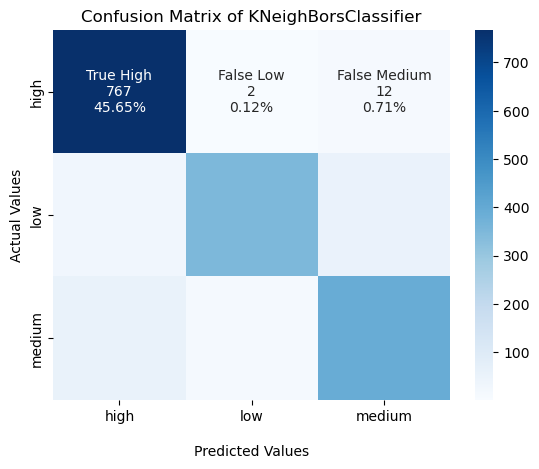

In [220]:
# Confusion Matrix
cm = confusion_matrix(y_train, y_knn_pred)
plot_confusion_matrix(cm, "KNeighBorsClassifier")

In [221]:
print('Perform Basic Predictions')
# Accuracy
print('Accuracy  = {:.4f}'.format(y_knn_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train, y_knn_pred, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train, y_knn_pred, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train, y_knn_pred, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train, y_knn_pred, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train, y_knn_pred, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train, y_knn_pred, average='weighted')))

Perform Basic Predictions
Accuracy  = 0.8988
Precision (macro) = 0.9029
Recall (macro)    = 0.8779
F1 Score (macro)  = 0.8877
Precision (weighted) = 0.9009
Recall (weighted)    = 0.8988
F1 Score (weighted)  = 0.8974


In [222]:
# Accuracy of 0% shows all predictions were wrong, serving as a baseline
print('Accuracy using prediction values:', accuracy_score(y_train, y_knn_pred))

y_knn_allfalse = np.zeros(len(X_train_tr), dtype=bool)
print('Accuracy using prediction values:', accuracy_score(y_train, y_knn_allfalse))

Accuracy using prediction values: 0.8988095238095238
Accuracy using prediction values: 0.0


#### 3. Perform Cross-Validated Prediction on Train Set

In [223]:
# Cross Validation (CV)
k_scores = cross_val_score(knn_model, X_train_tr, y_train, cv=5, scoring='accuracy')
print("Cross Validation: ", k_scores)
print("Mean Accuracy:", k_scores.mean())

# Predictions with CV
y_knn_cv = cross_val_predict(knn_model, X_train_tr, y_train, cv=5)

Cross Validation:  [0.86607143 0.86904762 0.82440476 0.81845238 0.79761905]
Mean Accuracy: 0.8351190476190476


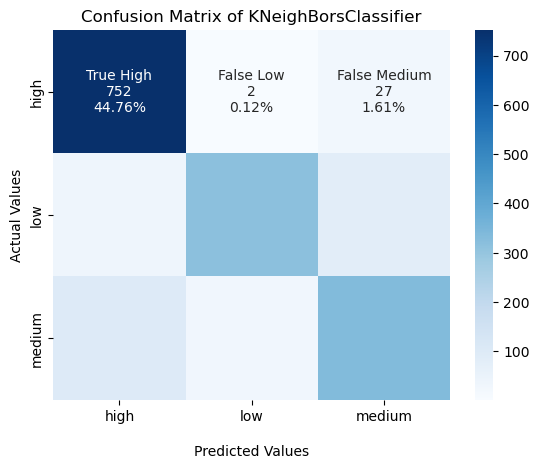

[[752   2  27]
 [ 35 317  83]
 [100  30 334]]


In [172]:
# Confusion Matrix
cm_cv = confusion_matrix(y_train, y_knn_cv)
plot_confusion_matrix(cm_cv, "KNeighBorsClassifier")
print(cm_cv)

In [173]:
print('Perform Cross Validation (CV)')
# Accuracy
y_knn_acc = accuracy_score(y_train, y_knn_cv)
print('Accuracy  = {:.4f}'.format(y_knn_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train, y_knn_cv, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train, y_knn_cv, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train, y_knn_cv, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train, y_knn_cv, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train, y_knn_cv, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train, y_knn_cv, average='weighted')))

Perform Cross Validation (CV)
Accuracy  = 0.8351
Precision (macro) = 0.8361
Recall (macro)    = 0.8038
F1 Score (macro)  = 0.8153
Precision (weighted) = 0.8371
Recall (weighted)    = 0.8351
F1 Score (weighted)  = 0.8318


In [224]:
# Function to plot PR curves for each class and display PR AUC
def plot_pr_curves(y_true, y_scores, class_labels):
    plt.figure(figsize=(6, 4))
    pr_auc = {}

    for i, label in enumerate(class_labels):
        precision, recall, _ = precision_recall_curve(y_true == label, y_scores[:, i])
        pr_auc[label] = average_precision_score(y_true == label, y_scores[:, i])
        plt.plot(recall, precision, label=f'Class {label} (AUC = {pr_auc[label]:0.2f})')

    plt.plot(np.linspace(0, 1, 20), np.linspace(1, 0, 20), 'k--')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Graph with AUC')
    plt.legend(loc='best')
    plt.grid(True)
    plt.axis([0, 1, 0, 1])
    plt.show()

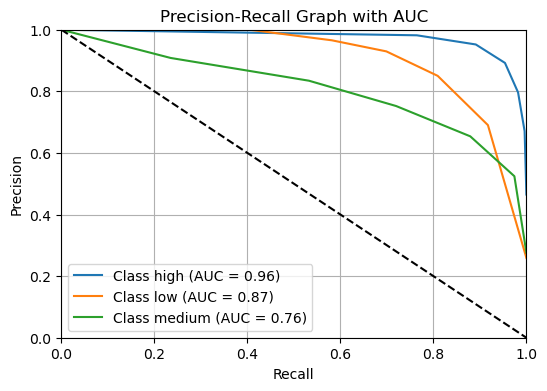

In [225]:
# Example usage with cross-validated predictions
y_knn_cv = cross_val_predict(knn_model, X_train_tr, y_train, cv=5, method='predict_proba')

# Plot the Precision-Recall curves and list PR AUC for each class
plot_pr_curves(y_train, y_knn_cv, class_labels)

In [226]:
# Function to plot ROC curves for each class and display ROC AUC
def plot_roc_curves(y_true, y_scores, class_labels):
    plt.figure(figsize=(10, 8))

    y_true_bin = label_binarize(y_true, classes=class_labels)

    roc_auc = {}

    for i, label in enumerate(class_labels):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc[label] = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {label} (area = {roc_auc[label]:0.2f})')

    fpr_macro, tpr_macro, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
    roc_auc["macro"] = auc(fpr_macro, tpr_macro)
    plt.plot(fpr_macro, tpr_macro, lw=2, label=f'Macro-average ROC curve (area = {roc_auc["macro"]:0.2f})')

    # Plot diagonal line for random guessing
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

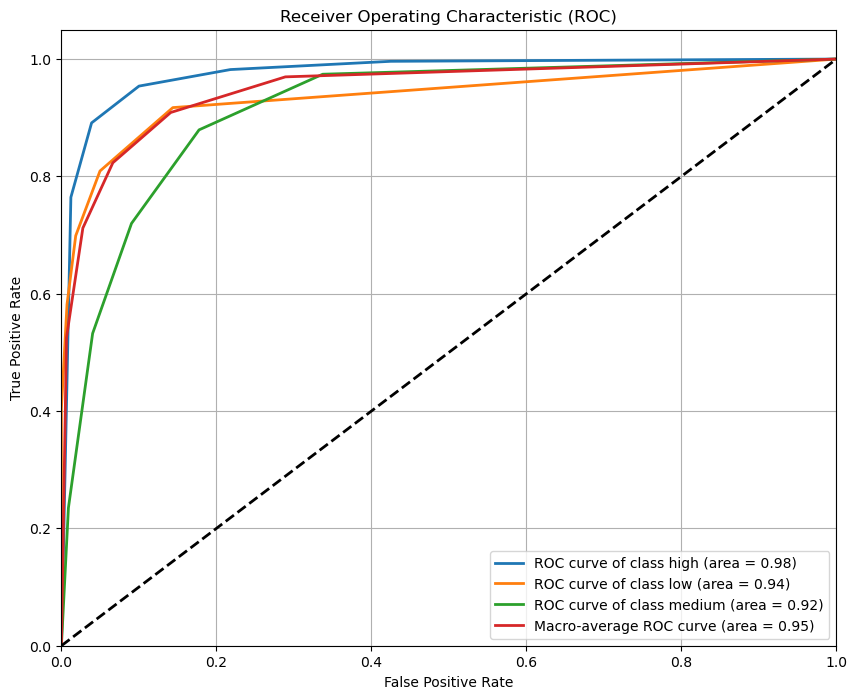

In [227]:
# Call Function
plot_roc_curves(y_train, y_knn_cv, class_labels)

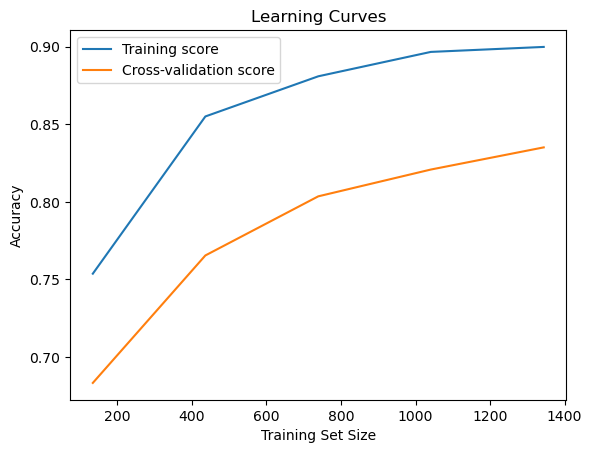

In [228]:
train_sizes, train_scores, test_scores = learning_curve(knn_model, X_train_tr, y_train, cv=5, scoring='accuracy')
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves')
plt.legend()
plt.show()

#### 4. Model Training on Test Set

In [229]:
# Predict on the test set
y_knn_test_pred = knn_model.predict(X_test_tr)

#### 5. Performance Analysis on Test Set

In [230]:
# Accuracy
y_knn_test_acc = accuracy_score(y_test, y_knn_test_pred)
print("Test accuracy: {:.4f}".format(y_knn_test_acc))

# Classification Report
y_class_report = classification_report(y_test, y_knn_test_pred)
print("\nClassification Report:\n", y_class_report)

print("Prediction on Test Set:\n", confusion_matrix(y_test, y_knn_test_pred))

Test accuracy: 0.8976

Classification Report:
               precision    recall  f1-score   support

        high       0.91      0.98      0.95       186
         low       0.97      0.81      0.88       122
      medium       0.81      0.86      0.83       112

    accuracy                           0.90       420
   macro avg       0.90      0.88      0.89       420
weighted avg       0.90      0.90      0.90       420

Prediction on Test Set:
 [[182   1   3]
 [  3  99  20]
 [ 14   2  96]]


#### 6. Perform Cross Validation on Test Set

In [231]:
y_knn_test_cv = cross_val_predict(knn_model, X_test_tr, y_test, cv=5)
print("CV Prediction on Test Set:\n", confusion_matrix(y_test, y_knn_test_cv))

CV Prediction on Test Set:
 [[175   2   9]
 [  5  83  34]
 [ 28  11  73]]


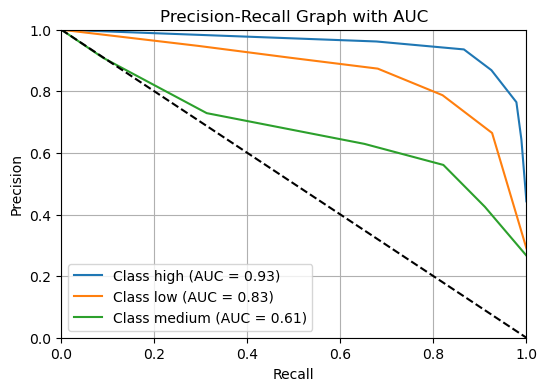

In [232]:
y_knn_test_cv = cross_val_predict(knn_model, X_test_tr, y_test, cv=5, method='predict_proba')
plot_pr_curves(y_test, y_knn_test_cv, class_labels)

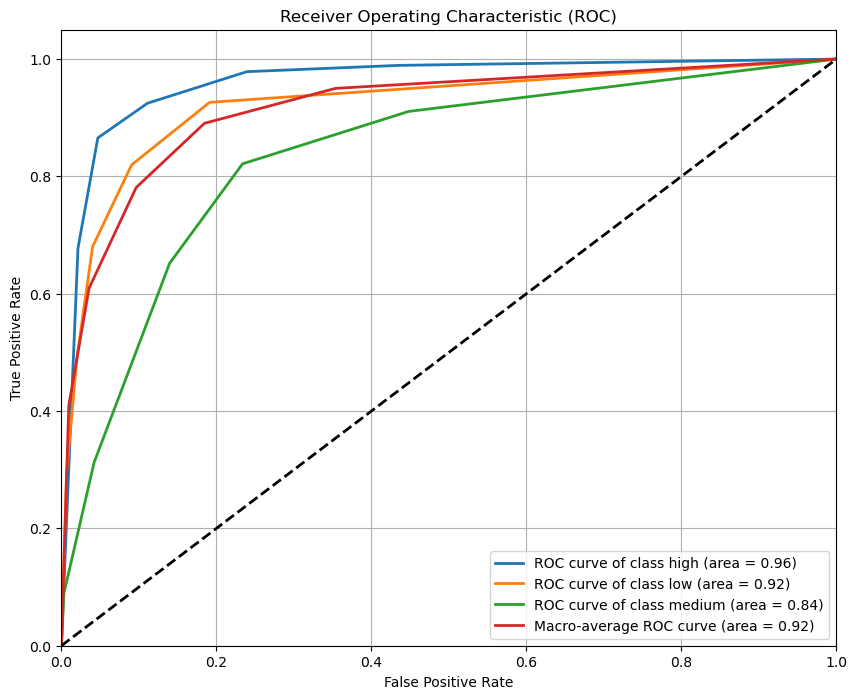

In [233]:
plot_roc_curves(y_test, y_knn_test_cv, class_labels)

### 2.4.2 After Resampling

#### 1. Model Training on Train Set

In [234]:
# Initialize kNN model
knn_model_smote = KNeighborsClassifier(n_neighbors = 5)

# Train the model
knn_model_smote.fit(X_train_res, y_train_res)

KNeighborsClassifier()

#### 1. Performance Analysis on Train Set with CV

In [235]:
# Predictions
y_knn_smote_pred = knn_model_smote.predict(X_train_res)

# Accuracy
y_knn_smote_acc = accuracy_score(y_train_res, y_knn_smote_pred)
print("Basic Training Accuracy: {:.2%}".format(y_knn_smote_acc))

Basic Training Accuracy: 94.92%


In [236]:
# Cross Validation (CV)
k_smote_scores = cross_val_score(knn_model_smote, X_train_res, y_train_res, cv=5, scoring='accuracy')
print("Cross Validation: ", k_smote_scores)
print("Mean Accuracy:", k_smote_scores.mean())

# Predictions with CV
y_knn_smote_cv = cross_val_predict(knn_model_smote, X_train_res, y_train_res, cv=5)

# Accuracy
y_knn_smote_cv_acc = accuracy_score(y_train_res, y_knn_smote_cv)
print("CV Training Accuracy: {:.2%}".format(y_knn_smote_cv_acc))

Cross Validation:  [0.90191898 0.87846482 0.86353945 0.94871795 0.95299145]
Mean Accuracy: 0.9091265285295137
CV Training Accuracy: 90.91%


In [237]:
# Classification Report
class_report_smote = classification_report(y_train_res, y_knn_smote_cv)
print("Classification Report:\n{}".format(class_report_smote))

Classification Report:
              precision    recall  f1-score   support

        high       0.94      0.93      0.94       781
         low       0.94      0.89      0.91       781
      medium       0.85      0.90      0.88       781

    accuracy                           0.91      2343
   macro avg       0.91      0.91      0.91      2343
weighted avg       0.91      0.91      0.91      2343



In [238]:
print('Perform SMOTE with CV')
# Accuracy
print('Accuracy  = {:.4f}'.format(y_knn_smote_cv_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train_res, y_knn_smote_cv, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train_res, y_knn_smote_cv, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train_res, y_knn_smote_cv, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train_res, y_knn_smote_cv, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train_res, y_knn_smote_cv, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train_res, y_knn_smote_cv, average='weighted')))

Perform SMOTE with CV
Accuracy  = 0.9091
Precision (macro) = 0.9108
Recall (macro)    = 0.9091
F1 Score (macro)  = 0.9094
Precision (weighted) = 0.9108
Recall (weighted)    = 0.9091
F1 Score (weighted)  = 0.9094


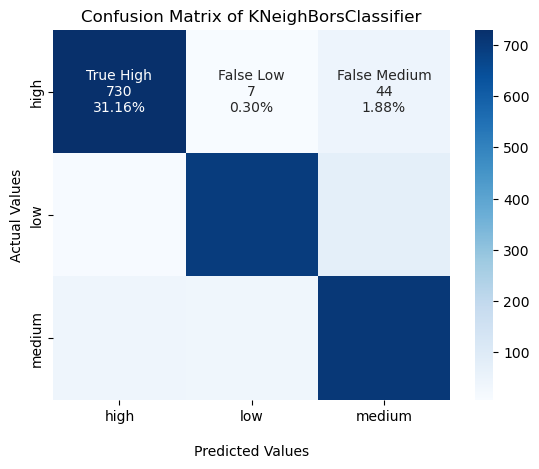

[[730   7  44]
 [ 11 694  76]
 [ 39  36 706]]


In [239]:
# Confusion Matrix
cm_smote = confusion_matrix(y_train_res, y_knn_smote_cv)
plot_confusion_matrix(cm_smote, "KNeighBorsClassifier")
print(cm_smote)

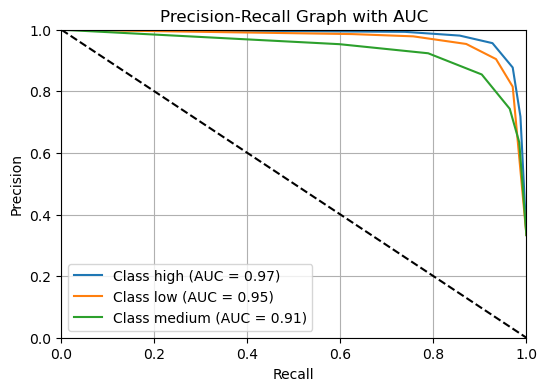

In [240]:
y_knn_smote_cv = cross_val_predict(knn_model_smote, X_train_res, y_train_res, cv=5, method='predict_proba')

# Call function
plot_pr_curves(y_train_res, y_knn_smote_cv, class_labels)

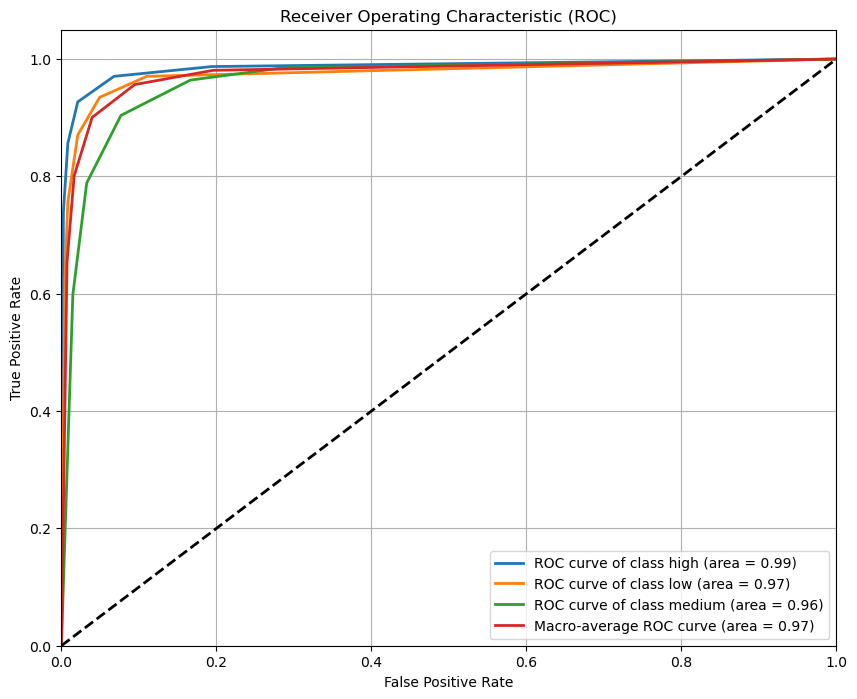

In [241]:
# Call Function
plot_roc_curves(y_train_res, y_knn_smote_cv, class_labels)

## Model 2: Support Vector Classifier (SVC)

### 2.4.1 Before Resampling

#### 1. Model Training on Train Set

In [242]:
# Initialize the SVM model with default parameters
svc_model = SVC(random_state=42, probability=True, class_weight='balanced')

# Train the model
svc_model.fit(X_train_tr, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

#### 2. Performance Analysis on Train Set

In [243]:
# Prediction
y_svc_pred = svc_model.predict(X_train_tr)

# Accuracy
y_svc_acc = accuracy_score(y_train, y_svc_pred)
print(f"SVM Model Accuracy: {y_svc_acc:.2%}")

SVM Model Accuracy: 98.45%


In [244]:
# Classification Report
class_report = classification_report(y_train, y_svc_pred)
print(class_report)

              precision    recall  f1-score   support

        high       1.00      0.99      0.99       781
         low       0.99      0.97      0.98       435
      medium       0.96      0.99      0.97       464

    accuracy                           0.98      1680
   macro avg       0.98      0.98      0.98      1680
weighted avg       0.98      0.98      0.98      1680



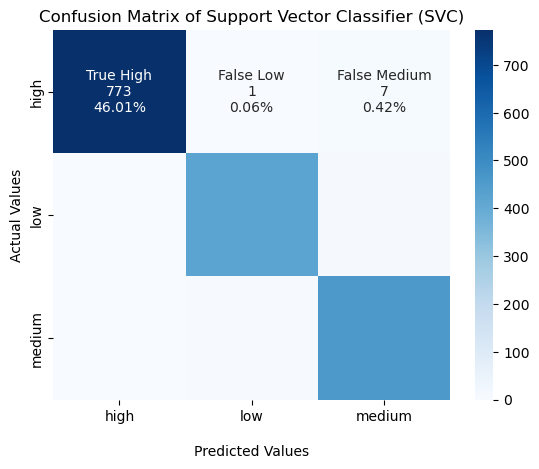

In [245]:
# Confusion Matrix
cm = confusion_matrix(y_train, y_svc_pred)
plot_confusion_matrix(cm, "Support Vector Classifier (SVC)")

In [246]:
print('Perform Basic Predictions')
# Accuracy
print('Accuracy  = {:.4f}'.format(y_svc_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train, y_svc_pred, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train, y_svc_pred, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train, y_svc_pred, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train, y_svc_pred, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train, y_svc_pred, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train, y_svc_pred, average='weighted')))

Perform Basic Predictions
Accuracy  = 0.9845
Precision (macro) = 0.9816
Recall (macro)    = 0.9831
F1 Score (macro)  = 0.9823
Precision (weighted) = 0.9848
Recall (weighted)    = 0.9845
F1 Score (weighted)  = 0.9846


#### 3. Perform Cross-Validated Prediction

In [247]:
# Cross Validation (CV)
k_scores = cross_val_score(svc_model, X_train_tr, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores: ", k_scores)
print("Mean CV Accuracy Score: ", k_scores.mean())

# Predictions with CV
y_svc_cv = cross_val_predict(svc_model, X_train_tr, y_train, cv=5)

Cross-Validation Accuracy Scores:  [0.95535714 0.94642857 0.94940476 0.94345238 0.94940476]
Mean CV Accuracy Score:  0.9488095238095238


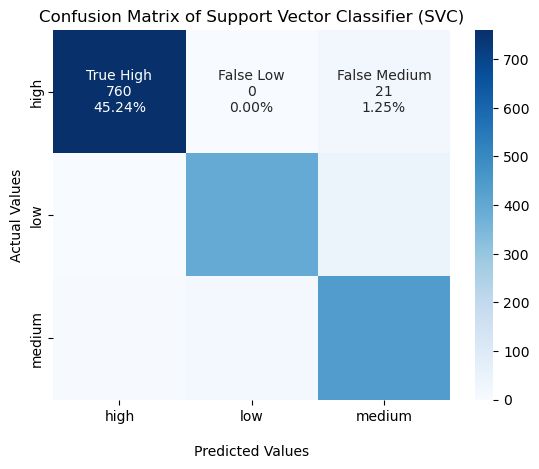

[[760   0  21]
 [  0 392  43]
 [  5  17 442]]


In [248]:
# Confusion Matrix
cm_cv = confusion_matrix(y_train, y_svc_cv)
plot_confusion_matrix(cm_cv, "Support Vector Classifier (SVC)")
print(cm_cv)

In [249]:
print('Perform Cross Validation (CV)')
# Accuracy
y_svc_acc = accuracy_score(y_train, y_svc_cv)
print('Accuracy  = {:.4f}'.format(y_svc_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train, y_svc_cv, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train, y_svc_cv, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train, y_svc_cv, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train, y_svc_cv, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train, y_svc_cv, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train, y_svc_cv, average='weighted')))

Perform Cross Validation (CV)
Accuracy  = 0.9488
Precision (macro) = 0.9418
Recall (macro)    = 0.9423
F1 Score (macro)  = 0.9411
Precision (weighted) = 0.9513
Recall (weighted)    = 0.9488
F1 Score (weighted)  = 0.9493


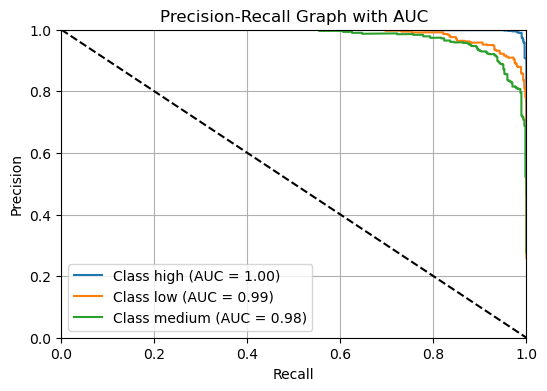

In [250]:
# Example usage with cross-validated predictions
y_svc_cv = cross_val_predict(svc_model, X_train_tr, y_train, cv=5, method='predict_proba')

# Plot the Precision-Recall curves and list PR AUC for each class
plot_pr_curves(y_train, y_svc_cv, class_labels)


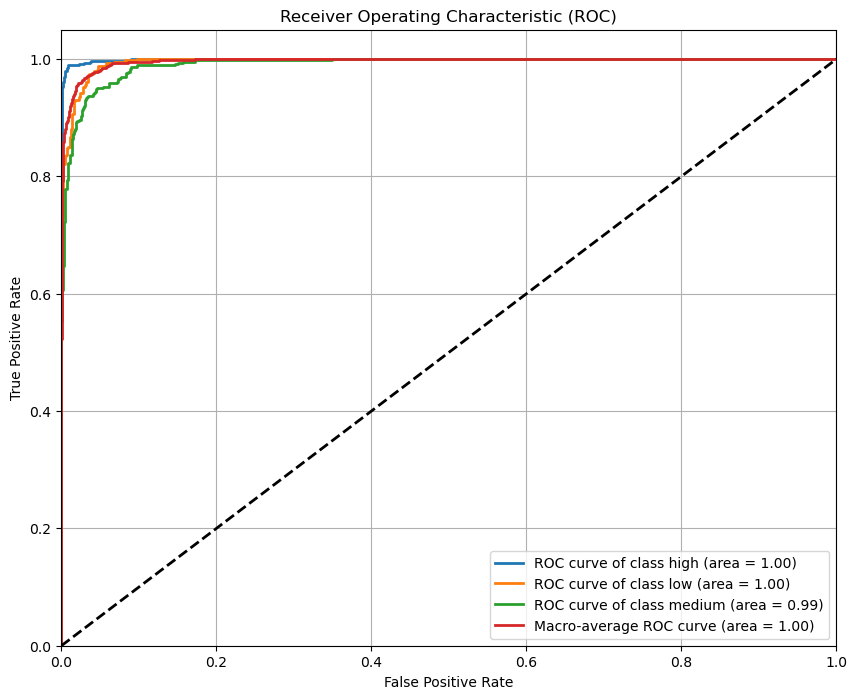

In [251]:
# Call Function
plot_roc_curves(y_train, y_svc_cv, class_labels)

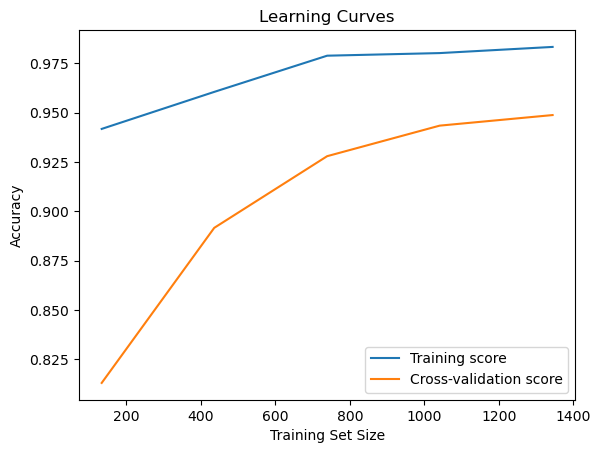

In [252]:
train_sizes, train_scores, test_scores = learning_curve(svc_model, X_train_tr, y_train, cv=5, scoring='accuracy')
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves')
plt.legend()
plt.show()

#### 4. Model Training on Test Set

In [254]:
# Predict on the test set
y_svc_test_pred = svc_model.predict(X_test_tr)

Test accuracy: 0.9667
              precision    recall  f1-score   support

        high       1.00      0.99      0.99       186
         low       0.97      0.93      0.95       122
      medium       0.92      0.96      0.94       112

    accuracy                           0.97       420
   macro avg       0.96      0.96      0.96       420
weighted avg       0.97      0.97      0.97       420



#### 5. Performance Analysis on Test Set

In [256]:
# Accuracy
y_svc_test_acc = accuracy_score(y_test, y_svc_test_pred)
print("Test accuracy: {:.4f}".format(y_svc_test_acc))

# Classification Report
y_class_report = classification_report(y_test, y_svc_test_pred)
print(y_class_report)

print("Prediction on Test Set:\n", confusion_matrix(y_test, y_svc_test_pred))

Test accuracy: 0.9667
              precision    recall  f1-score   support

        high       1.00      0.99      0.99       186
         low       0.97      0.93      0.95       122
      medium       0.92      0.96      0.94       112

    accuracy                           0.97       420
   macro avg       0.96      0.96      0.96       420
weighted avg       0.97      0.97      0.97       420

Prediction on Test Set:
 [[184   0   2]
 [  0 114   8]
 [  0   4 108]]


#### 6. Perform Cross Validation on Test Set

In [260]:
y_svc_test_cv = cross_val_predict(svc_model, X_test_tr, y_test, cv=5)
print("CV Prediction on Test Set:\n", confusion_matrix(y_test, y_svc_test_cv))

CV Prediction on Test Set:
 [[171   0  15]
 [  0 105  17]
 [  0   9 103]]


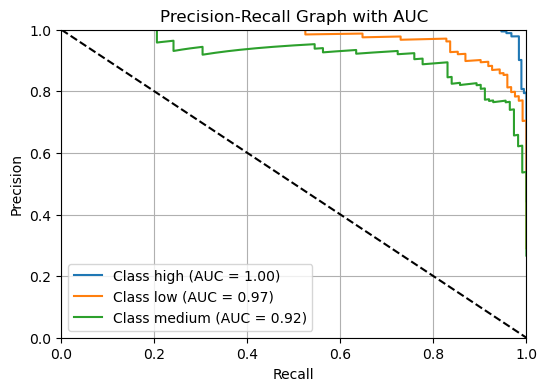

In [261]:
y_svc_test_cv = cross_val_predict(svc_model, X_test_tr, y_test, cv=5, method='predict_proba')
plot_pr_curves(y_test, y_svc_test_cv, class_labels)

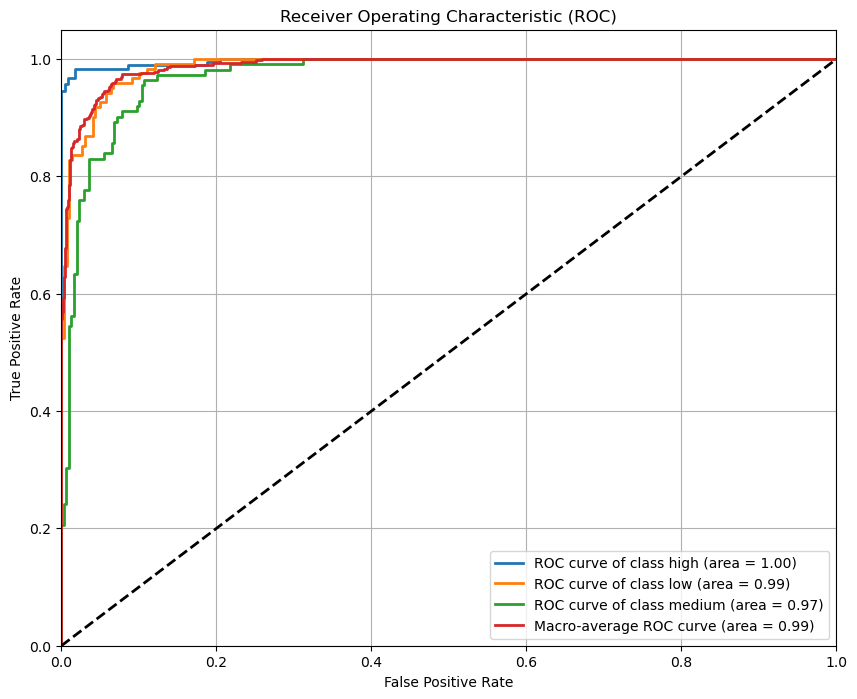

In [262]:
plot_roc_curves(y_test, y_svc_test_cv, class_labels)

### 2.4.2 After Resampling

#### 1. Model Training on Train Set

In [263]:
# Initialize kNN model
svc_model_smote = SVC(random_state=42, probability=True, class_weight='balanced')

# Train the model
svc_model_smote.fit(X_train_res, y_train_res)

SVC(class_weight='balanced', probability=True, random_state=42)

#### 2. Performance Analysis on Train Set with CV

In [264]:
# Predictions
y_svc_smote_pred = svc_model_smote.predict(X_train_res)

# Accuracy
y_svc_smote_acc = accuracy_score(y_train_res, y_svc_smote_pred)
print("Basic Training Accuracy: {:.2%}".format(y_svc_smote_acc))

Basic Training Accuracy: 99.27%


In [265]:
# Cross Validation (CV)
k_smote_scores = cross_val_score(svc_model_smote, X_train_res, y_train_res, cv=5, scoring='accuracy')
print("Cross Validation: ", k_smote_scores)
print("Mean Accuracy:", k_smote_scores.mean())

# Predictions with CV
y_svc_smote_cv = cross_val_predict(svc_model_smote, X_train_res, y_train_res, cv=5)

# Accuracy
y_svc_smote_cv_acc = accuracy_score(y_train_res, y_svc_smote_cv)
print("CV Training Accuracy: {:.2%}".format(y_svc_smote_cv_acc))

Cross Validation:  [0.96375267 0.96801706 0.95948827 0.98504274 0.99358974]
Mean Accuracy: 0.9739780948736172
CV Training Accuracy: 97.40%


In [266]:
# Classification Report
class_report_smote = classification_report(y_train_res, y_svc_smote_cv)
print("Classification Report:\n{}".format(class_report_smote))

Classification Report:
              precision    recall  f1-score   support

        high       1.00      0.99      0.99       781
         low       0.98      0.96      0.97       781
      medium       0.94      0.98      0.96       781

    accuracy                           0.97      2343
   macro avg       0.97      0.97      0.97      2343
weighted avg       0.97      0.97      0.97      2343



In [267]:
print('Perform SMOTE with CV')
# Accuracy
print('Accuracy  = {:.4f}'.format(y_svc_smote_cv_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train_res, y_svc_smote_cv, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train_res, y_svc_smote_cv, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train_res, y_svc_smote_cv, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train_res, y_svc_smote_cv, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train_res, y_svc_smote_cv, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train_res, y_svc_smote_cv, average='weighted')))

Perform SMOTE with CV
Accuracy  = 0.9740
Precision (macro) = 0.9745
Recall (macro)    = 0.9740
F1 Score (macro)  = 0.9741
Precision (weighted) = 0.9745
Recall (weighted)    = 0.9740
F1 Score (weighted)  = 0.9741


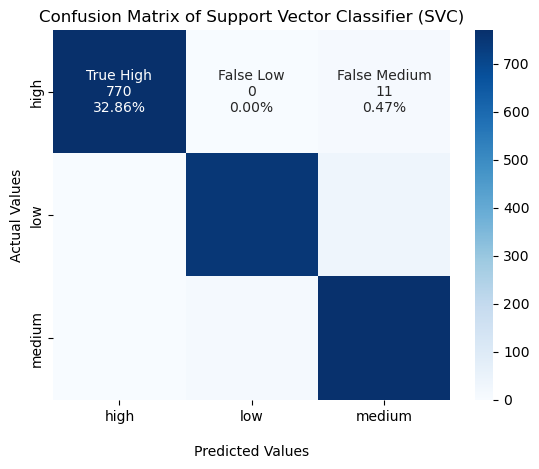

[[770   0  11]
 [  0 747  34]
 [  3  13 765]]


In [268]:
# Confusion Matrix
cm_smote = confusion_matrix(y_train_res, y_svc_smote_cv)
plot_confusion_matrix(cm_smote, "Support Vector Classifier (SVC)")
print(cm_smote)

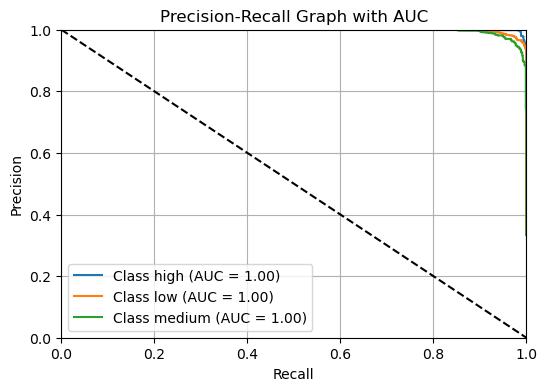

In [269]:
y_svc_smote_cv = cross_val_predict(svc_model_smote, X_train_res, y_train_res, cv=5, method='predict_proba')

# Call function
plot_pr_curves(y_train_res, y_svc_smote_cv, class_labels)

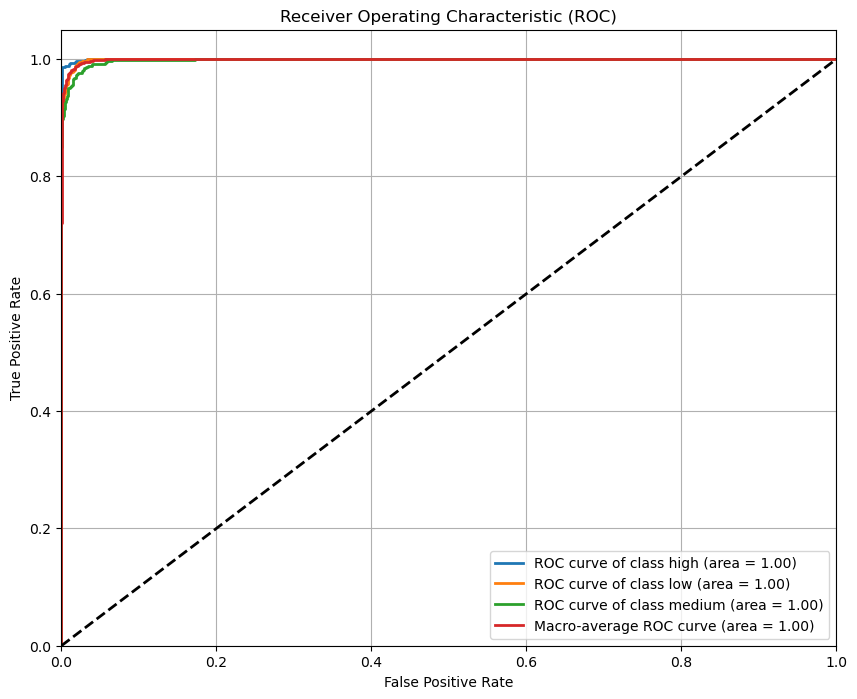

In [270]:
# Call Function
plot_roc_curves(y_train_res, y_svc_smote_cv, class_labels)

## Model 3: Logistic Regression

### 2.4.1 Before Resampling

#### 1. Model Training on Train Set

In [271]:
# Initialize the Logistic Regression Model
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs',max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train_tr, y_train)

LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

#### 2. Performance Analysis on Train Set

In [272]:
# Prediction
y_lr_pred = lr_model.predict(X_train_tr)

# Accuracy
y_lr_acc = accuracy_score(y_train, y_lr_pred)
print(f"Logistic Regression Model Accuracy: {y_lr_acc:.2%}")

Logistic Regression Model Accuracy: 98.39%


In [273]:
# Classification Report
class_report = classification_report(y_train, y_lr_pred)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

        high       1.00      0.99      1.00       781
         low       0.99      0.96      0.97       435
      medium       0.95      0.99      0.97       464

    accuracy                           0.98      1680
   macro avg       0.98      0.98      0.98      1680
weighted avg       0.98      0.98      0.98      1680



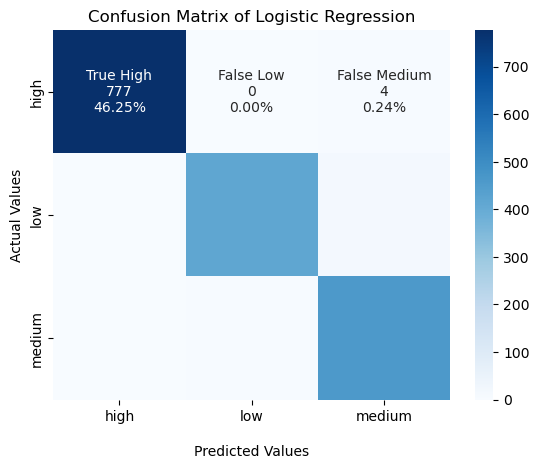

[[777   0   4]
 [  0 417  18]
 [  1   4 459]]


In [274]:
# Confusion Matrix
cm = confusion_matrix(y_train, y_lr_pred)
plot_confusion_matrix(cm, "Logistic Regression")
print(cm)

In [275]:
print('Perform Basic Predictions')
# Accuracy
print('Accuracy  = {:.4f}'.format(y_lr_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train, y_lr_pred, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train, y_lr_pred, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train, y_lr_pred, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train, y_lr_pred, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train, y_lr_pred, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train, y_lr_pred, average='weighted')))

Perform Basic Predictions
Accuracy  = 0.9839
Precision (macro) = 0.9812
Recall (macro)    = 0.9809
F1 Score (macro)  = 0.9808
Precision (weighted) = 0.9843
Recall (weighted)    = 0.9839
F1 Score (weighted)  = 0.9840


#### 3. Perform Cross-Validated Prediction

In [276]:
# Cross Validation (CV)
k_scores = cross_val_score(lr_model, X_train_tr, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores: ", k_scores)
print("Mean CV Accuracy Score: ", k_scores.mean())

# Predictions with CV
y_lr_cv = cross_val_predict(lr_model, X_train_tr, y_train, cv=5)

Cross-Validation Accuracy Scores:  [0.98214286 0.95833333 0.9702381  0.98214286 0.9702381 ]
Mean CV Accuracy Score:  0.9726190476190476


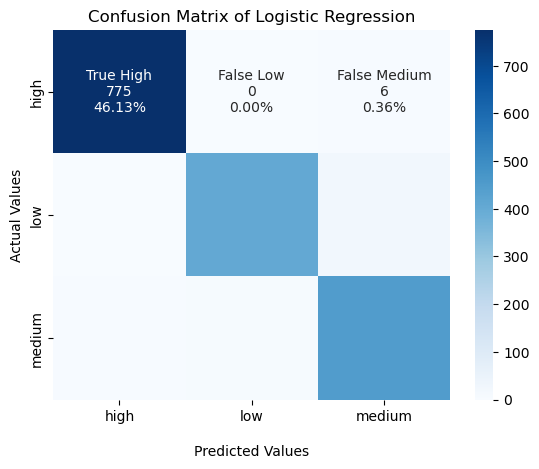

[[775   0   6]
 [  0 408  27]
 [  4   9 451]]


In [277]:
# Confusion Matrix
cm_cv = confusion_matrix(y_train, y_lr_cv)
plot_confusion_matrix(cm_cv, "Logistic Regression")
print(cm_cv)

In [278]:
print('Perform Cross Validation (CV)')
# Accuracy
y_lr_acc = accuracy_score(y_train, y_lr_cv)
print('Accuracy  = {:.4f}'.format(y_lr_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train, y_lr_cv, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train, y_lr_cv, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train, y_lr_cv, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train, y_lr_cv, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train, y_lr_cv, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train, y_lr_cv, average='weighted')))

Perform Cross Validation (CV)
Accuracy  = 0.9726
Precision (macro) = 0.9684
Recall (macro)    = 0.9674
F1 Score (macro)  = 0.9676
Precision (weighted) = 0.9732
Recall (weighted)    = 0.9726
F1 Score (weighted)  = 0.9727


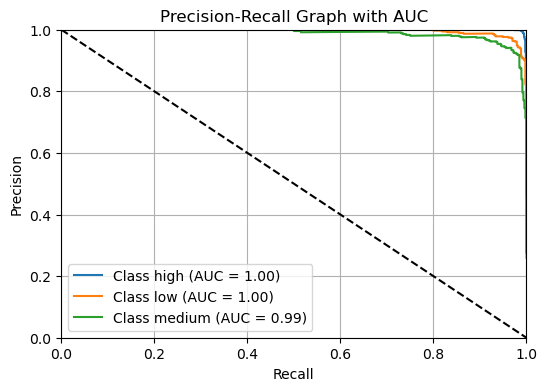

In [279]:
# Example usage with cross-validated predictions
y_lr_cv = cross_val_predict(lr_model, X_train_tr, y_train, cv=5, method='predict_proba')

# Plot the Precision-Recall curves and list PR AUC for each class
plot_pr_curves(y_train, y_lr_cv, class_labels)


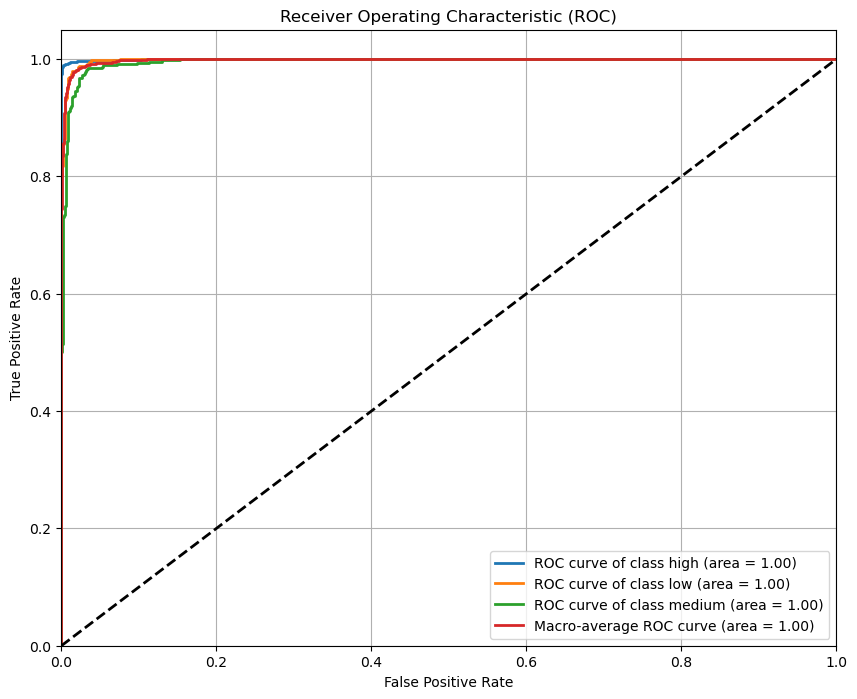

In [280]:
# Plot ROC Curve
plot_roc_curves(y_train, y_lr_cv, class_labels)

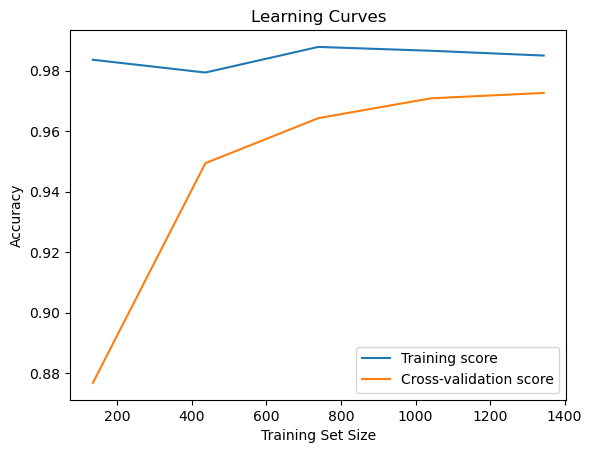

In [281]:
train_sizes, train_scores, test_scores = learning_curve(lr_model, X_train_tr, y_train, cv=5, scoring='accuracy')
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves')
plt.legend()
plt.show()

#### 4. Model Training on Test Set

In [282]:
# Predict on the test set
y_lr_test_pred = lr_model.predict(X_test_tr)

#### 5. Performance Analysis on Test Set

In [284]:
# Accuracy
y_lr_test_acc = accuracy_score(y_test, y_lr_test_pred)
print("Test accuracy: {:.4f}".format(y_lr_test_acc))

# Classification Report
y_class_report = classification_report(y_test, y_lr_test_pred)
print(y_class_report)

print("Prediction on Test Set:\n", confusion_matrix(y_test, y_lr_test_pred))

Test accuracy: 0.9738
              precision    recall  f1-score   support

        high       0.99      1.00      1.00       186
         low       0.99      0.93      0.96       122
      medium       0.92      0.98      0.95       112

    accuracy                           0.97       420
   macro avg       0.97      0.97      0.97       420
weighted avg       0.97      0.97      0.97       420

Prediction on Test Set:
 [[186   0   0]
 [  0 113   9]
 [  1   1 110]]


#### 6. Perform Cross Validation on Test Set

In [285]:
y_lr_test_cv = cross_val_predict(lr_model, X_test_tr, y_test, cv=5)
print("CV Prediction on Test Set:\n", confusion_matrix(y_test, y_lr_test_cv))

CV Prediction on Test Set:
 [[184   0   2]
 [  0 110  12]
 [  2   8 102]]


In [285]:
y_lr_test_cv = cross_val_predict(lr_model, X_test_tr, y_test, cv=5)
print("CV Prediction on Test Set:\n", confusion_matrix(y_test, y_lr_test_cv))

CV Prediction on Test Set:
 [[184   0   2]
 [  0 110  12]
 [  2   8 102]]


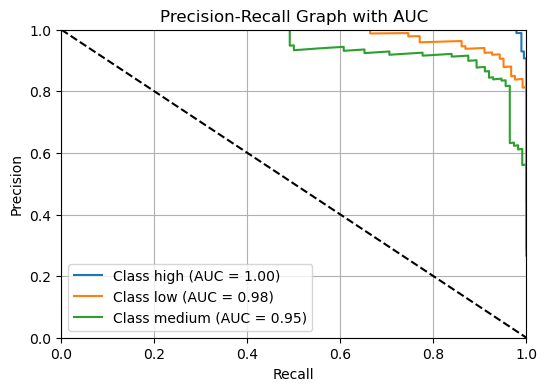

In [286]:
y_lr_test_cv = cross_val_predict(lr_model, X_test_tr, y_test, cv=5, method='predict_proba')
plot_pr_curves(y_test, y_lr_test_cv, class_labels)

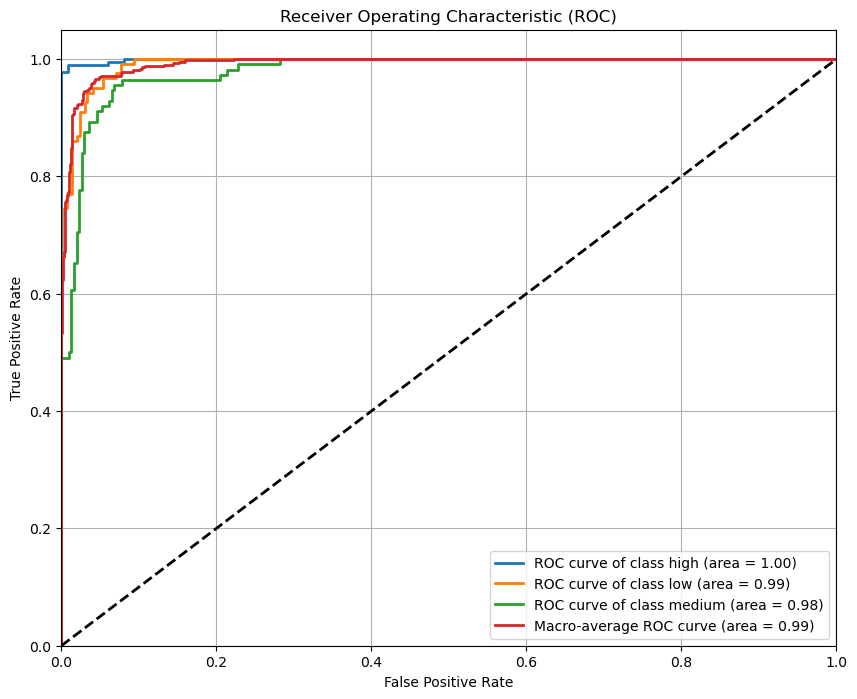

In [287]:
plot_roc_curves(y_test, y_lr_test_cv, class_labels)

### 2.4.2 After Resampling

#### 1. Model Training on Train Set

In [288]:
# Initialize the Logistic Regression Model
lr_model_smote = LogisticRegression(multi_class='multinomial', solver='lbfgs',max_iter=1000, random_state=42)

# Train the model
lr_model_smote.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

#### 2. Performance Analysis on Train Set with CV

In [289]:
# Predictions
y_lr_smote_pred = lr_model_smote.predict(X_train_res)

# Accuracy
y_lr_smote_acc = accuracy_score(y_train_res, y_lr_smote_pred)
print("Basic Training Accuracy: {:.2%}".format(y_lr_smote_acc))

Basic Training Accuracy: 98.85%


In [290]:
# Cross Validation (CV)
k_smote_scores = cross_val_score(lr_model_smote, X_train_res, y_train_res, cv=5, scoring='accuracy')
print("Cross Validation: ", k_smote_scores)
print("Mean Accuracy:", k_smote_scores.mean())

# Predictions with CV
y_lr_smote_cv = cross_val_predict(lr_model_smote, X_train_res, y_train_res, cv=5)

# Accuracy
y_lr_smote_cv_acc = accuracy_score(y_train_res, y_lr_smote_cv)
print("CV Training Accuracy: {:.2%}".format(y_lr_smote_cv_acc))

Cross Validation:  [0.97228145 0.97654584 0.97014925 0.98717949 0.9957265 ]
Mean Accuracy: 0.9803765057496401
CV Training Accuracy: 98.04%


In [291]:
# Classification Report
class_report_smote = classification_report(y_train_res, y_lr_smote_cv)
print("Classification Report:\n{}".format(class_report_smote))

Classification Report:
              precision    recall  f1-score   support

        high       1.00      0.98      0.99       781
         low       0.99      0.97      0.98       781
      medium       0.95      0.99      0.97       781

    accuracy                           0.98      2343
   macro avg       0.98      0.98      0.98      2343
weighted avg       0.98      0.98      0.98      2343



In [292]:
print('Perform SMOTE with CV')
# Accuracy
print('Accuracy  = {:.4f}'.format(y_lr_smote_cv_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train_res, y_lr_smote_cv, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train_res, y_lr_smote_cv, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train_res, y_lr_smote_cv, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train_res, y_lr_smote_cv, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train_res, y_lr_smote_cv, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train_res, y_lr_smote_cv, average='weighted')))

Perform SMOTE with CV
Accuracy  = 0.9804
Precision (macro) = 0.9810
Recall (macro)    = 0.9804
F1 Score (macro)  = 0.9805
Precision (weighted) = 0.9810
Recall (weighted)    = 0.9804
F1 Score (weighted)  = 0.9805


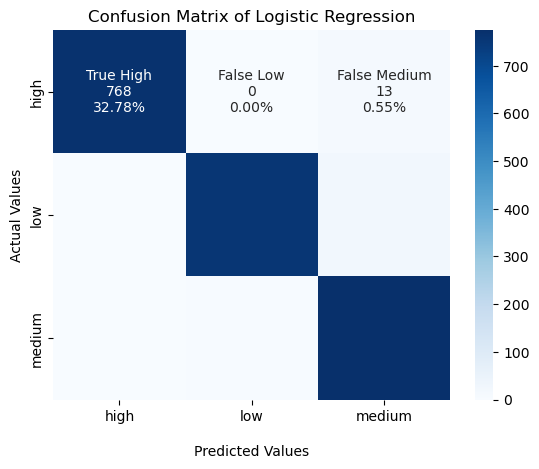

[[768   0  13]
 [  0 754  27]
 [  1   5 775]]


In [293]:
# Confusion Matrix
cm_smote = confusion_matrix(y_train_res, y_lr_smote_cv)
plot_confusion_matrix(cm_smote, "Logistic Regression")
print(cm_smote)

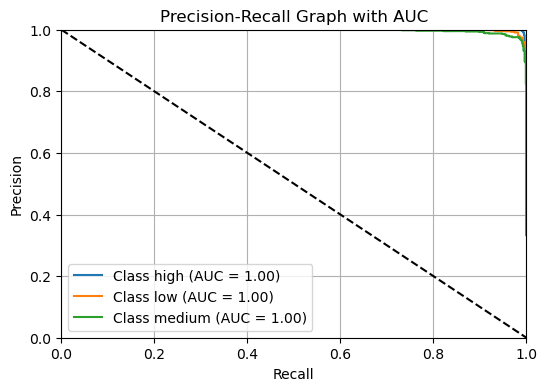

In [294]:
y_lr_smote_cv = cross_val_predict(lr_model_smote, X_train_res, y_train_res, cv=5, method='predict_proba')

# Plot PR Curves
plot_pr_curves(y_train_res, y_lr_smote_cv, class_labels)

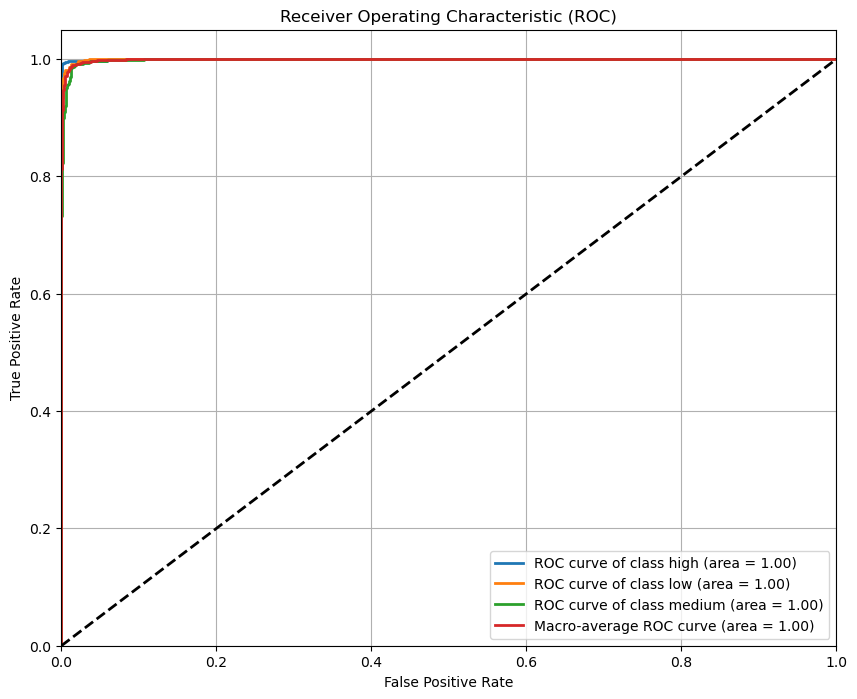

In [295]:
# Call Function
plot_roc_curves(y_train_res, y_lr_smote_cv, class_labels)

## Model 4: Random Forest

### 2.4.1 Before Resampling

#### 1. Model Training on Train Set

In [296]:
# Initialize the Random Forest model with default parameters
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

# Train the model on the training data
rf_model.fit(X_train_tr, y_train)

RandomForestClassifier(random_state=42)

#### 2. Performance Analysis on Train Set

In [297]:
# Prediction
y_rf_pred = rf_model.predict(X_train_tr)

# Accuracy
y_rf_acc = accuracy_score(y_train, y_rf_pred)
print(f"Random Forest Model Accuracy: {y_rf_acc:.2%}")

Random Forest Model Accuracy: 100.00%


In [298]:
# Classification Report
y_class_report = classification_report(y_train, y_rf_pred)
print(y_class_report)

              precision    recall  f1-score   support

        high       1.00      1.00      1.00       781
         low       1.00      1.00      1.00       435
      medium       1.00      1.00      1.00       464

    accuracy                           1.00      1680
   macro avg       1.00      1.00      1.00      1680
weighted avg       1.00      1.00      1.00      1680



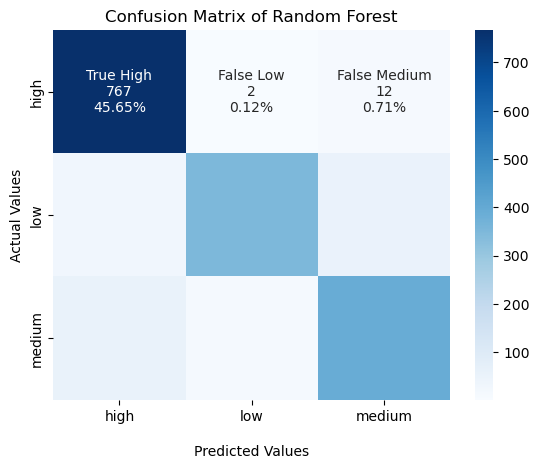

[[767   2  12]
 [ 31 351  53]
 [ 57  15 392]]


In [299]:
# Confusion Matrix
cm = confusion_matrix(y_train, y_knn_pred)
plot_confusion_matrix(cm, "Random Forest")
print(cm)

In [300]:
print('Perform Basic Predictions')
# Accuracy
print('Accuracy  = {:.4f}'.format(y_rf_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train, y_rf_pred, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train, y_rf_pred, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train, y_rf_pred, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train, y_rf_pred, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train, y_rf_pred, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train, y_rf_pred, average='weighted')))

Perform Basic Predictions
Accuracy  = 1.0000
Precision (macro) = 1.0000
Recall (macro)    = 1.0000
F1 Score (macro)  = 1.0000
Precision (weighted) = 1.0000
Recall (weighted)    = 1.0000
F1 Score (weighted)  = 1.0000


#### 3. Perform Cross-Validated Prediction

In [301]:
# Cross Validation (CV)
k_scores = cross_val_score(rf_model, X_train_tr, y_train, cv=5, scoring='accuracy')
print("Cross Validation: ", k_scores)
print("Mean Accuracy:", k_scores.mean())

# Predictions with CV
y_rf_cv = cross_val_predict(rf_model, X_train_tr, y_train, cv=5)

Cross Validation:  [0.95535714 0.94642857 0.96130952 0.95238095 0.9672619 ]
Mean Accuracy: 0.9565476190476192


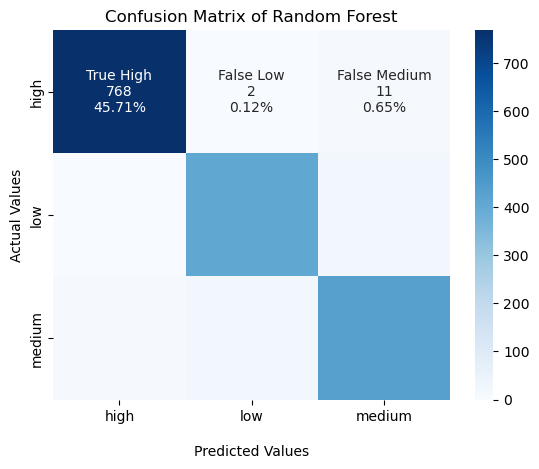

[[768   2  11]
 [  0 409  26]
 [  9  25 430]]


In [302]:
# Confusion Matrix
cm_cv = confusion_matrix(y_train, y_rf_cv)
plot_confusion_matrix(cm_cv, "Random Forest")
print(cm_cv)

In [303]:
print('Perform Cross Validation (CV)')
# Accuracy
y_rf_acc = accuracy_score(y_train, y_rf_cv)
print('Accuracy  = {:.4f}'.format(y_rf_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train, y_rf_cv, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train, y_rf_cv, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train, y_rf_cv, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train, y_rf_cv, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train, y_rf_cv, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train, y_rf_cv, average='weighted')))

Perform Cross Validation (CV)
Accuracy  = 0.9565
Precision (macro) = 0.9491
Recall (macro)    = 0.9501
F1 Score (macro)  = 0.9496
Precision (weighted) = 0.9567
Recall (weighted)    = 0.9565
F1 Score (weighted)  = 0.9566


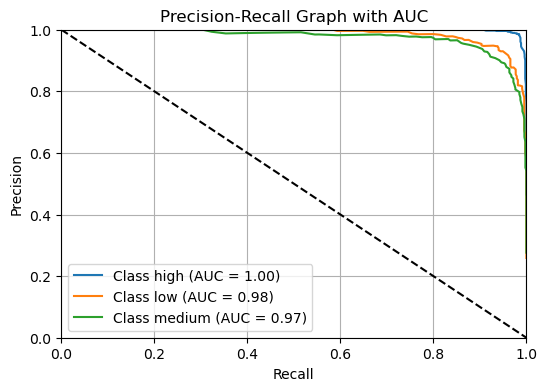

In [304]:
# Example usage with cross-validated predictions
y_rf_cv = cross_val_predict(rf_model, X_train_tr, y_train, cv=5, method='predict_proba')

# Plot the Precision-Recall curves and list PR AUC for each class
plot_pr_curves(y_train, y_rf_cv, class_labels)

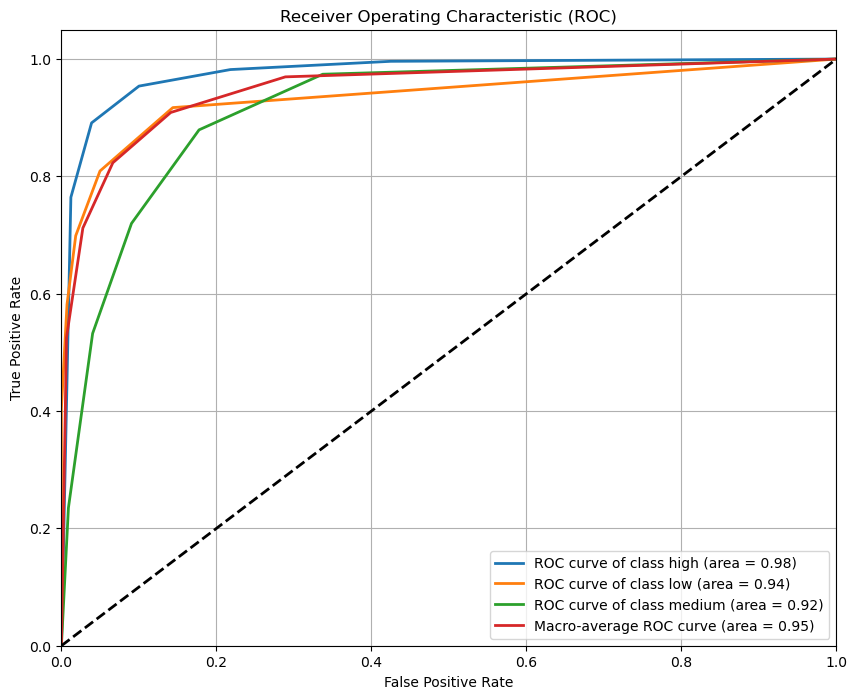

In [305]:
# Plot ROC Curves
plot_roc_curves(y_train, y_knn_cv, class_labels)

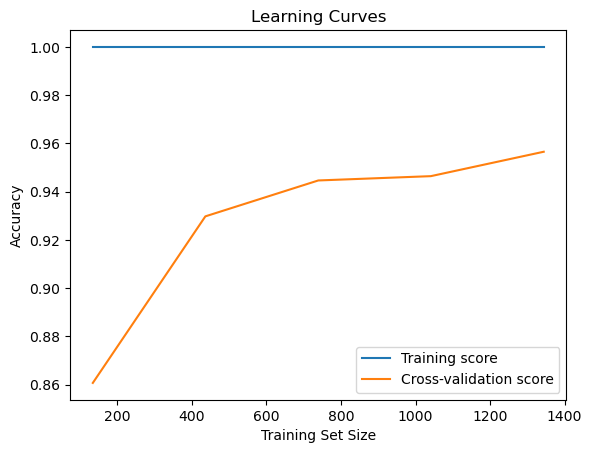

In [306]:
train_sizes, train_scores, test_scores = learning_curve(rf_model, X_train_tr, y_train, cv=5, scoring='accuracy')
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves')
plt.legend()
plt.show()

#### 4. Model Training on Test Set

In [307]:
# Predict on the test set
y_rf_test_pred = rf_model.predict(X_test_tr)

#### 5. Performance Analysis on Test Set

In [308]:
# Accuracy
y_rf_test_acc = accuracy_score(y_test, y_rf_test_pred)
print("Test accuracy: {:.4f}".format(y_rf_test_acc))

# Classification Report
y_class_report = classification_report(y_test, y_rf_test_pred)
print(y_class_report)

print("Prediction on Test Set:\n", confusion_matrix(y_test, y_rf_test_pred))

Test accuracy: 0.9738
              precision    recall  f1-score   support

        high       0.99      0.99      0.99       186
         low       0.97      0.95      0.96       122
      medium       0.95      0.96      0.96       112

    accuracy                           0.97       420
   macro avg       0.97      0.97      0.97       420
weighted avg       0.97      0.97      0.97       420

Prediction on Test Set:
 [[185   1   0]
 [  0 116   6]
 [  1   3 108]]


#### 6. Perform Cross Validation on Test Set

In [312]:
y_rf_test_cv = cross_val_predict(rf_model, X_test_tr, y_test, cv=5)
print("CV Prediction on Test Set:\n", confusion_matrix(y_test, y_rf_test_cv))

CV Prediction on Test Set:
 [[180   1   5]
 [  0 109  13]
 [  7   8  97]]


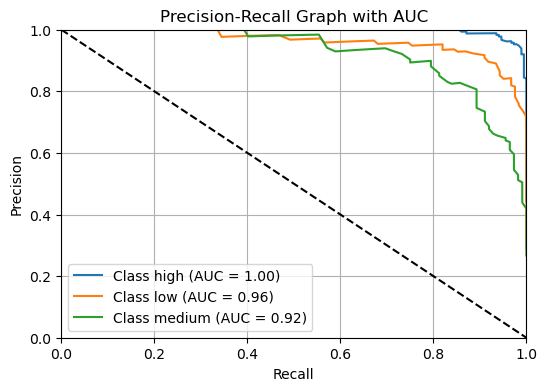

In [313]:
y_rf_test_cv = cross_val_predict(rf_model, X_test_tr, y_test, cv=5, method='predict_proba')
plot_pr_curves(y_test, y_rf_test_cv, class_labels)

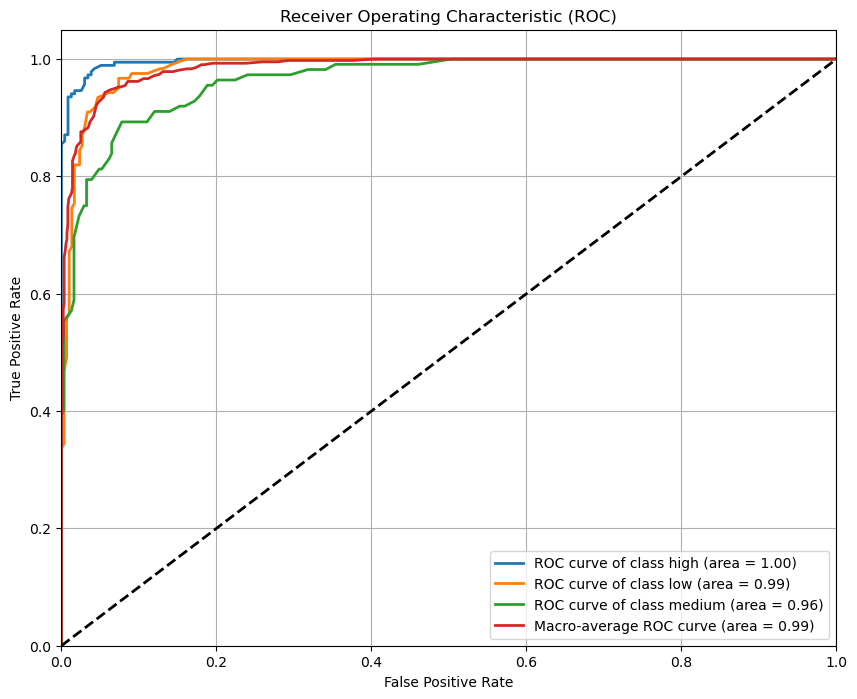

In [314]:
plot_roc_curves(y_test, y_rf_test_cv, class_labels)

### 2.4.2 After Resampling

#### 1. Model Training on Train Set

In [315]:
# Initialize the Random Forest model with default parameters
rf_model_smote = RandomForestClassifier(random_state=42, n_estimators=100)

# Train the model on the training data
rf_model_smote.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

#### 2. Performance Analysis on Train Set with CV

In [316]:
# Predictions
y_rf_smote_pred = rf_model_smote.predict(X_train_res)

# Accuracy
y_rf_smote_acc = accuracy_score(y_train_res, y_rf_smote_pred)
print("Basic Training Accuracy: {:.2%}".format(y_rf_smote_acc))

Basic Training Accuracy: 100.00%


In [317]:
# Cross Validation (CV)
k_smote_scores = cross_val_score(rf_model_smote, X_train_res, y_train_res, cv=5, scoring='accuracy')
print("Cross Validation: ", k_smote_scores)
print("Mean Accuracy:", k_smote_scores.mean())

# Predictions with CV
y_rf_smote_cv = cross_val_predict(rf_model_smote, X_train_res, y_train_res, cv=5)

# Accuracy
y_rf_smote_cv_acc = accuracy_score(y_train_res, y_rf_smote_cv)
print("CV Training Accuracy: {:.2%}".format(y_rf_smote_cv_acc))

Cross Validation:  [0.96801706 0.96162047 0.96162047 0.98931624 0.98931624]
Mean Accuracy: 0.9739780948736172
CV Training Accuracy: 97.40%


In [318]:
# Classification Report
class_report_smote = classification_report(y_train_res, y_rf_smote_cv)
print("Classification Report:\n{}".format(class_report_smote))

Classification Report:
              precision    recall  f1-score   support

        high       0.99      0.98      0.99       781
         low       0.97      0.98      0.97       781
      medium       0.96      0.97      0.96       781

    accuracy                           0.97      2343
   macro avg       0.97      0.97      0.97      2343
weighted avg       0.97      0.97      0.97      2343



In [319]:
print('Perform SMOTE with CV')
# Accuracy
print('Accuracy  = {:.4f}'.format(y_rf_smote_cv_acc))
# Precision, Recall, and F1 Score
print('Precision (macro) = {:.4f}'.format(precision_score(y_train_res, y_rf_smote_cv, average='macro')))
print('Recall (macro)    = {:.4f}'.format(recall_score(y_train_res, y_rf_smote_cv, average='macro')))
print('F1 Score (macro)  = {:.4f}'.format(f1_score(y_train_res, y_rf_smote_cv, average='macro')))

# For more detailed analysis, you can use weighted averages
print('Precision (weighted) = {:.4f}'.format(precision_score(y_train_res, y_rf_smote_cv, average='weighted')))
print('Recall (weighted)    = {:.4f}'.format(recall_score(y_train_res, y_rf_smote_cv, average='weighted')))
print('F1 Score (weighted)  = {:.4f}'.format(f1_score(y_train_res, y_rf_smote_cv, average='weighted')))

Perform SMOTE with CV
Accuracy  = 0.9740
Precision (macro) = 0.9741
Recall (macro)    = 0.9740
F1 Score (macro)  = 0.9740
Precision (weighted) = 0.9741
Recall (weighted)    = 0.9740
F1 Score (weighted)  = 0.9740


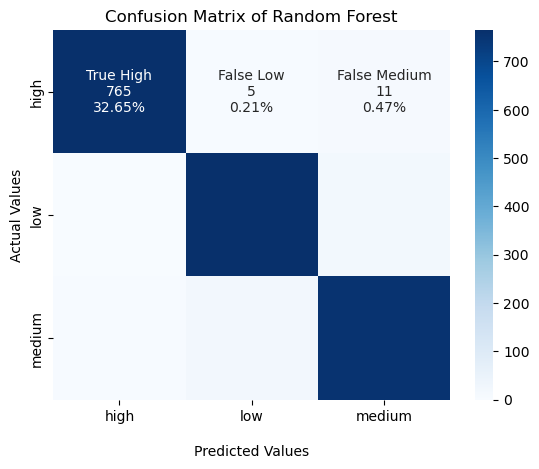

[[765   5  11]
 [  0 763  18]
 [  5  22 754]]


In [320]:
# Confusion Matrix
cm_smote = confusion_matrix(y_train_res, y_rf_smote_cv)
plot_confusion_matrix(cm_smote, "Random Forest")
print(cm_smote)

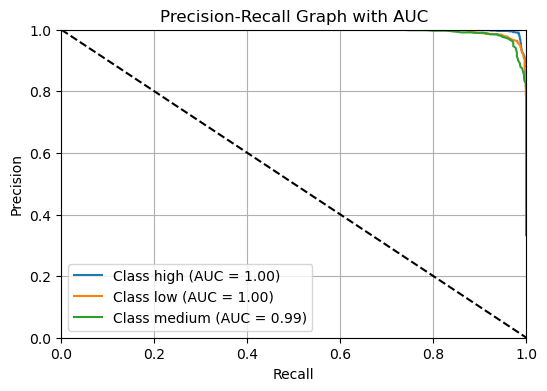

In [321]:
# Confusion Matrix
y_rf_smote_cv = cross_val_predict(rf_model_smote, X_train_res, y_train_res, cv=5, method='predict_proba')

# Call function
plot_pr_curves(y_train_res, y_rf_smote_cv, class_labels)

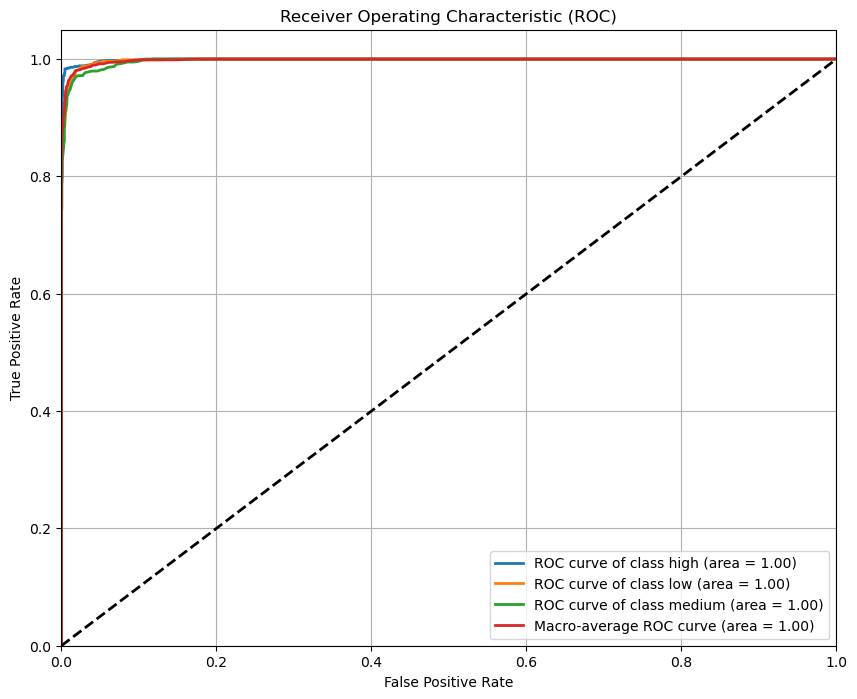

In [322]:
# Call Function
plot_roc_curves(y_train_res, y_rf_smote_cv, class_labels)

# 2.5 Model Fining and Tuning

## Model 1: k-Nearest Neighbor (kNN)

#### 1. Perform Grid Search

In [323]:
# Define the parameter grid
param_grid = {
    'n_neighbors': [7,9,11,13,15,17,19,21],   # Testing k values
    'weights' : ['uniform','distance'],
    'metric': ['euclidean', 'manhattan'] # Distance metrics
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=knn_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X_train_tr, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [7, 9, 11, 13, 15, 17, 19, 21],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

#### 2. Find the Best Model

In [324]:
# Get the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Get the best model
best_model_knn = grid_search.best_estimator_

best_model_knn.fit(X_train_tr, y_train)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best Score: 0.8785714285714287


KNeighborsClassifier(metric='manhattan', n_neighbors=9, weights='distance')

#### 3. Test the Best Model using Test Set

In [325]:
# Predict on the test set
y_pred_test = best_model_knn.predict(X_test_tr)

# Evaluate performance
y_acc_test = accuracy_score(y_test, y_pred_test)
print("Test Accuracy with Best Parameters: {:.2%}".format(y_acc_test))

Test Accuracy with Best Parameters: 90.95%


In [326]:
# Classification Report
y_class_report = classification_report(y_test, y_pred_test)
print("\nClassification Report:\n", y_class_report)


Classification Report:
               precision    recall  f1-score   support

        high       0.93      0.99      0.96       186
         low       0.96      0.82      0.88       122
      medium       0.83      0.88      0.85       112

    accuracy                           0.91       420
   macro avg       0.91      0.89      0.90       420
weighted avg       0.91      0.91      0.91       420



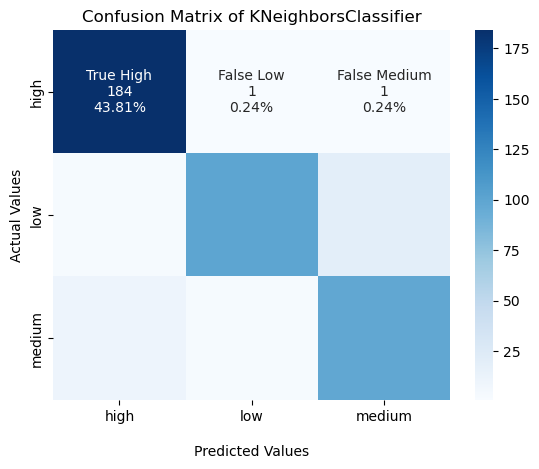

In [327]:
cm_test = confusion_matrix(y_test, y_pred_test)
plot_confusion_matrix(cm_test, "KNeighborsClassifier")

## Model 2: Support Vector Classifier (SVC)

#### 1. Perform Grid Search

In [328]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto'],
    'degree': [2, 3, 4]  # Only used if kernel='poly'
}

# Create GridSearchCV object
grid_search = GridSearchCV(svc_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train_tr, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5,
             estimator=SVC(class_weight='balanced', probability=True,
                           random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'degree': [2, 3, 4],
                         'gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy', verbose=2)

#### 2. Find the Best Model

In [329]:
# Best parameters and best score
print("Best Parameters:\n", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Get the best model
best_model_svc = grid_search.best_estimator_

best_model_svc.fit(X_train_tr, y_train)

Best Parameters:
 {'C': 10, 'degree': 2, 'gamma': 0.001, 'kernel': 'linear'}
Best Score: 0.9916666666666668


SVC(C=10, class_weight='balanced', degree=2, gamma=0.001, kernel='linear',
    probability=True, random_state=42)

#### 3. Test the Best Model using Test Set

In [330]:
# Predict on the test set
y_pred_test = best_model_svc.predict(X_test_tr)

# Evaluate performance
print(f"Training Accuracy: {accuracy_score(y_test, y_pred_test):.2%}")

Training Accuracy: 98.10%


In [331]:
# Classification Report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

        high       0.98      0.99      0.99       186
         low       0.98      0.98      0.98       122
      medium       0.97      0.96      0.96       112

    accuracy                           0.98       420
   macro avg       0.98      0.98      0.98       420
weighted avg       0.98      0.98      0.98       420



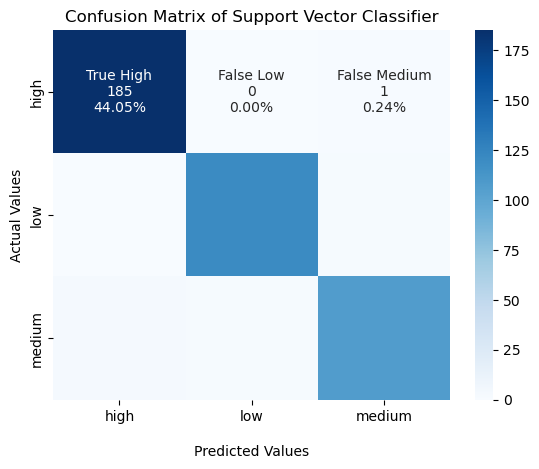

In [332]:
cm_test = confusion_matrix(y_test, y_pred_test)
plot_confusion_matrix(cm_test, "Support Vector Classifier")

## Model 3: Logistic Regression

#### 1. Perform Grid Search

In [333]:
# Define the hyperparameter grid to search
param_grid = [
    {'C': [0.01, 0.1, 1, 10, 100],
     'solver': ['newton-cg', 'lbfgs', 'sag'],
     'multi_class': ['multinomial'],
     'max_iter': [100, 200, 300, 500]},
    
    {'C': [0.01, 0.1, 1, 10, 100],
     'solver': ['liblinear'],
     'multi_class': ['ovr'],
     'max_iter': [100, 200, 300, 500]}
]

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=lr_model, param_grid=param_grid, 
                           cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X_train_tr, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000,
                                          multi_class='multinomial',
                                          random_state=42),
             n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1, 10, 100],
                          'max_iter': [100, 200, 300, 500],
                          'multi_class': ['multinomial'],
                          'solver': ['newton-cg', 'lbfgs', 'sag']},
                         {'C': [0.01, 0.1, 1, 10, 100],
                          'max_iter': [100, 200, 300, 500],
                          'multi_class': ['ovr'], 'solver': ['liblinear']}],
             scoring='accuracy', verbose=1)

#### 2. Find the Best Model

In [334]:
# Get the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Get the best model
best_model_lr = grid_search.best_estimator_

best_model_lr.fit(X_train_tr, y_train)

Best Parameters: {'C': 100, 'max_iter': 100, 'multi_class': 'multinomial', 'solver': 'newton-cg'}
Best Cross-Validation Accuracy: 0.9892857142857144


LogisticRegression(C=100, multi_class='multinomial', random_state=42,
                   solver='newton-cg')

#### 3. Test the Best Model using Test Set

In [335]:
# Predict on the test set
y_pred_test = best_model_lr.predict(X_test_tr)

# Evaluate performance
y_acc_test = accuracy_score(y_test, y_pred_test)
print("Test Accuracy with Best Parameters: {:.2%}".format(y_acc_test))

Test Accuracy with Best Parameters: 97.86%


In [336]:
# Classification Report
y_class_report = classification_report(y_test, y_pred_test)
print("\nClassification Report:\n", y_class_report)


Classification Report:
               precision    recall  f1-score   support

        high       0.99      0.99      0.99       186
         low       0.98      0.97      0.98       122
      medium       0.96      0.96      0.96       112

    accuracy                           0.98       420
   macro avg       0.98      0.98      0.98       420
weighted avg       0.98      0.98      0.98       420



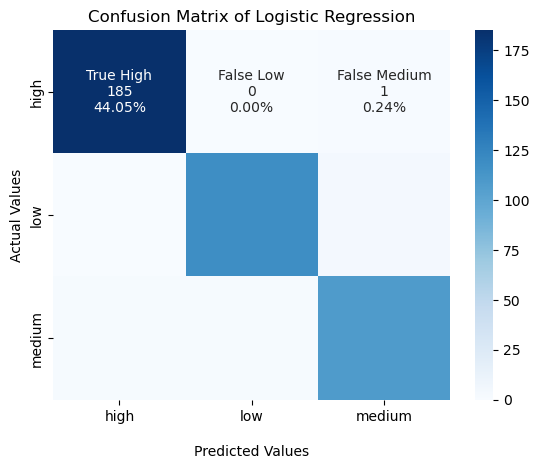

In [337]:
cm_test = confusion_matrix(y_test, y_pred_test)
plot_confusion_matrix(cm_test, "Logistic Regression")

## Model 4: Random Forest

#### 1. Perform Grid Search

In [338]:
# Define the parameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],  # 'auto' replaced with 'sqrt' and 'log2'
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV
randomized_search = RandomizedSearchCV(
    estimator=rf_model,                 # The model to tune
    param_distributions=param_grid,     # Parameter grid to search
    n_iter=20,                          # Number of parameter settings to sample
    cv=3,                               # Number of cross-validation folds
    scoring='accuracy',                 # Evaluation metric
    verbose=1,                          # Verbosity level
    n_jobs=-1,                          # Number of jobs to run in parallel
    random_state=42                     # Seed for reproducibility
)

# Fit the RandomizedSearchCV model
randomized_search.fit(X_train_tr, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, scoring='accuracy', verbose=1)

#### 2. Find the Best Model

In [127]:
# Extract the best parameters and score
print("Best Parameters:", randomized_search.best_params_)
print("Best Cross-Validation Accuracy:", randomized_search.best_score_)

# Extract the best model from RandomizedSearchCV
best_model_rf = randomized_search.best_estimator_

best_model_rf.fit(X_train_tr, y_train)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': False}
Best Cross-Validation Accuracy: 0.955952380952381


RandomForestClassifier(bootstrap=False, max_depth=40, min_samples_leaf=2,
                       n_estimators=300, random_state=42)

#### 3. Test the Best Model using Test Set

In [128]:
# Predict on the test set
y_pred_test = best_model_rf.predict(X_test_tr)

# Evaluate performance
y_acc_test = accuracy_score(y_test, y_pred_test)
print("Test Accuracy with Best Parameters: {:.2%}".format(y_acc_test))

Test Accuracy with Best Parameters: 97.38%


In [129]:
# Classification Report
y_class_report = classification_report(y_test, y_pred_test)
print("\nClassification Report:\n", y_class_report)


Classification Report:
               precision    recall  f1-score   support

        high       0.99      0.99      0.99       186
         low       0.97      0.95      0.96       122
      medium       0.95      0.96      0.96       112

    accuracy                           0.97       420
   macro avg       0.97      0.97      0.97       420
weighted avg       0.97      0.97      0.97       420



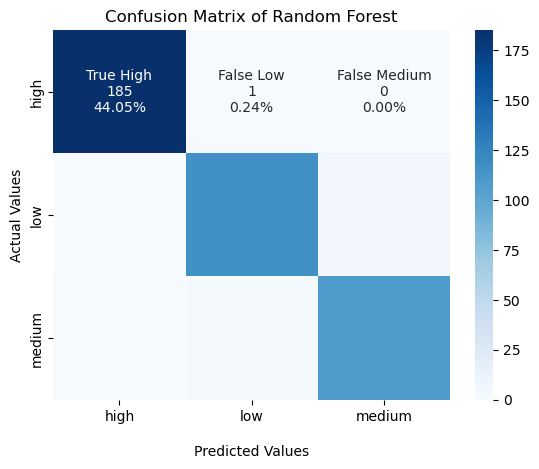

In [130]:
cm_test = confusion_matrix(y_test, y_pred_test)
plot_confusion_matrix(cm_test, "Random Forest")

# 3.0 Model Comparison

### 3.1 Compare Accuracy, Precision, Recall and F1 Score

#### 1. Imbalanced Training Dataset

In [131]:
# Re-code
y_knn_cv = cross_val_predict(knn_model, X_train_tr, y_train, cv=5)
y_svc_cv = cross_val_predict(svc_model, X_train_tr, y_train, cv=5)
y_lr_cv = cross_val_predict(lr_model, X_train_tr, y_train, cv=5)
y_rf_cv = cross_val_predict(rf_model, X_train_tr, y_train, cv=5)

# Compare the Accuracy, Precision, Recall and f1 score
print('            | K-Nearest Neighbour | Support Vector Classifier | Logistic Regression | Random Forest |')
print('Accuracy  = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(accuracy_score(y_train, y_knn_cv), accuracy_score(y_train, y_svc_cv), accuracy_score(y_train, y_lr_cv), accuracy_score(y_train, y_rf_cv)))
print('Precision = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(precision_score(y_train, y_knn_cv, average='macro'), precision_score(y_train, y_svc_cv, average='macro'), precision_score(y_train, y_lr_cv, average='macro'), precision_score(y_train, y_rf_cv, average='macro')))
print('Recall    = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(recall_score(y_train, y_knn_cv, average='macro'), recall_score(y_train, y_svc_cv, average='macro'), recall_score(y_train, y_lr_cv, average='macro'), recall_score(y_train, y_rf_cv, average='macro')))
print('f1 Score  = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(f1_score(y_train, y_knn_cv, average='macro'), f1_score(y_train, y_svc_cv, average='macro'), f1_score(y_train, y_lr_cv, average='macro'), f1_score(y_train, y_rf_cv, average='macro')))

            | K-Nearest Neighbour | Support Vector Classifier | Logistic Regression | Random Forest |
Accuracy  = |       0.8351        |           0.9488          |        0.9726       |     0.9565    |
Precision = |       0.8361        |           0.9418          |        0.9684       |     0.9491    |
Recall    = |       0.8038        |           0.9423          |        0.9674       |     0.9501    |
f1 Score  = |       0.8153        |           0.9411          |        0.9676       |     0.9496    |


#### 2. Imbalanced Unseen Data

In [132]:
# Re-code
y_knn_test_cv = cross_val_predict(knn_model, X_test_tr, y_test, cv=5)
y_svc_test_cv = cross_val_predict(svc_model, X_test_tr, y_test, cv=5)
y_lr_test_cv = cross_val_predict(lr_model, X_test_tr, y_test, cv=5)
y_rf_test_cv = cross_val_predict(rf_model, X_test_tr, y_test, cv=5)

# Compare the Accuracy, Precision, Recall and f1 score
print('            | K-Nearest Neighbour | Support Vector Classifier | Logistic Regression | Random Forest |')
print('Accuracy  = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(accuracy_score(y_test, y_knn_test_cv), accuracy_score(y_test, y_svc_test_cv), accuracy_score(y_test, y_lr_test_cv), accuracy_score(y_test, y_rf_test_cv)))
print('Precision = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(precision_score(y_test, y_knn_test_cv, average='macro'), precision_score(y_test, y_svc_test_cv, average='macro'), precision_score(y_test, y_lr_test_cv, average='macro'), precision_score(y_test, y_rf_test_cv, average='macro')))
print('Recall    = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(recall_score(y_test, y_knn_test_cv, average='macro'), recall_score(y_test, y_svc_test_cv, average='macro'), recall_score(y_test, y_lr_test_cv, average='macro'), recall_score(y_test, y_rf_test_cv, average='macro')))
print('f1 Score  = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(f1_score(y_test, y_knn_test_cv, average='macro'), f1_score(y_test, y_svc_test_cv, average='macro'), f1_score(y_test, y_lr_test_cv, average='macro'), f1_score(y_test, y_rf_test_cv, average='macro')))

            | K-Nearest Neighbour | Support Vector Classifier | Logistic Regression | Random Forest |
Accuracy  = |       0.7881        |           0.9024          |        0.9429       |     0.9190    |
Precision = |       0.7784        |           0.8947          |        0.9336       |     0.9099    |
Recall    = |       0.7577        |           0.8999          |        0.9339       |     0.9091    |
f1 Score  = |       0.7634        |           0.8939          |        0.9336       |     0.9094    |


#### 3. Balanced Trained Dataset

In [133]:
# Re-code
y_knn_smote_cv = cross_val_predict(knn_model_smote, X_train_res, y_train_res, cv=5)
y_svc_smote_cv = cross_val_predict(svc_model_smote, X_train_res, y_train_res, cv=5)
y_lr_smote_cv = cross_val_predict(lr_model_smote, X_train_res, y_train_res, cv=5)
y_rf_smote_cv = cross_val_predict(rf_model_smote, X_train_res, y_train_res, cv=5)

# Compare the Accuracy, Precision, Recall and f1 score
print('            | K-Nearest Neighbour | Support Vector Classifier | Logistic Regression | Random Forest |')
print('Accuracy  = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(accuracy_score(y_train_res, y_knn_smote_cv), accuracy_score(y_train_res, y_svc_smote_cv), accuracy_score(y_train_res, y_lr_smote_cv), accuracy_score(y_train_res, y_rf_smote_cv)))
print('Precision = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(precision_score(y_train_res, y_knn_smote_cv, average='macro'), precision_score(y_train_res, y_svc_smote_cv, average='macro'), precision_score(y_train_res, y_lr_smote_cv, average='macro'), precision_score(y_train_res, y_rf_smote_cv, average='macro')))
print('Recall    = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(recall_score(y_train_res, y_knn_smote_cv, average='macro'), recall_score(y_train_res, y_svc_smote_cv, average='macro'), recall_score(y_train_res, y_lr_smote_cv, average='macro'), recall_score(y_train_res, y_rf_smote_cv, average='macro')))
print('f1 Score  = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(f1_score(y_train_res, y_knn_smote_cv, average='macro'), f1_score(y_train_res, y_svc_smote_cv, average='macro'), f1_score(y_train_res, y_lr_smote_cv, average='macro'), f1_score(y_train_res, y_rf_smote_cv, average='macro')))

            | K-Nearest Neighbour | Support Vector Classifier | Logistic Regression | Random Forest |
Accuracy  = |       0.9091        |           0.9740          |        0.9804       |     0.9740    |
Precision = |       0.9108        |           0.9745          |        0.9810       |     0.9741    |
Recall    = |       0.9091        |           0.9740          |        0.9804       |     0.9740    |
f1 Score  = |       0.9094        |           0.9741          |        0.9805       |     0.9740    |


#### 4. Balanced Unseen Data

In [134]:
# Re-code
y_knn_smote_test_cv = cross_val_predict(knn_model_smote, X_test_res, y_test_res, cv=5)
y_svc_smote_test_cv = cross_val_predict(svc_model_smote, X_test_res, y_test_res, cv=5)
y_lr_smote_test_cv = cross_val_predict(lr_model_smote, X_test_res, y_test_res, cv=5)
y_rf_smote_test_cv = cross_val_predict(rf_model_smote, X_test_res, y_test_res, cv=5)

# Compare the Accuracy, Precision, Recall and f1 score
print('            | K-Nearest Neighbour | Support Vector Classifier | Logistic Regression | Random Forest |')
print('Accuracy  = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(accuracy_score(y_test_res, y_knn_smote_test_cv), accuracy_score(y_test_res, y_svc_smote_test_cv), accuracy_score(y_test_res, y_lr_smote_test_cv), accuracy_score(y_test_res, y_rf_smote_test_cv)))
print('Precision = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(precision_score(y_test_res, y_knn_smote_test_cv, average='macro'), precision_score(y_test_res, y_svc_smote_test_cv, average='macro'), precision_score(y_test_res, y_lr_smote_test_cv, average='macro'), precision_score(y_test_res, y_rf_smote_test_cv, average='macro')))
print('Recall    = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(recall_score(y_test_res, y_knn_smote_test_cv, average='macro'), recall_score(y_test_res, y_svc_smote_test_cv, average='macro'), recall_score(y_test_res, y_lr_smote_test_cv, average='macro'), recall_score(y_test_res, y_rf_smote_test_cv, average='macro')))
print('f1 Score  = |       {:.4f}        |           {:.4f}          |        {:.4f}       |     {:.4f}    |'.format(f1_score(y_test_res, y_knn_smote_test_cv, average='macro'), f1_score(y_test_res, y_svc_smote_test_cv, average='macro'), f1_score(y_test_res, y_lr_smote_test_cv, average='macro'), f1_score(y_test_res, y_rf_smote_test_cv, average='macro')))

            | K-Nearest Neighbour | Support Vector Classifier | Logistic Regression | Random Forest |
Accuracy  = |       0.8441        |           0.9337          |        0.9498       |     0.9373    |
Precision = |       0.8509        |           0.9387          |        0.9518       |     0.9371    |
Recall    = |       0.8441        |           0.9337          |        0.9498       |     0.9373    |
f1 Score  = |       0.8455        |           0.9345          |        0.9500       |     0.9372    |


### 3.2 Comparison on PR Curve using Best Model

#### 1. Imbalanced Training Dataset

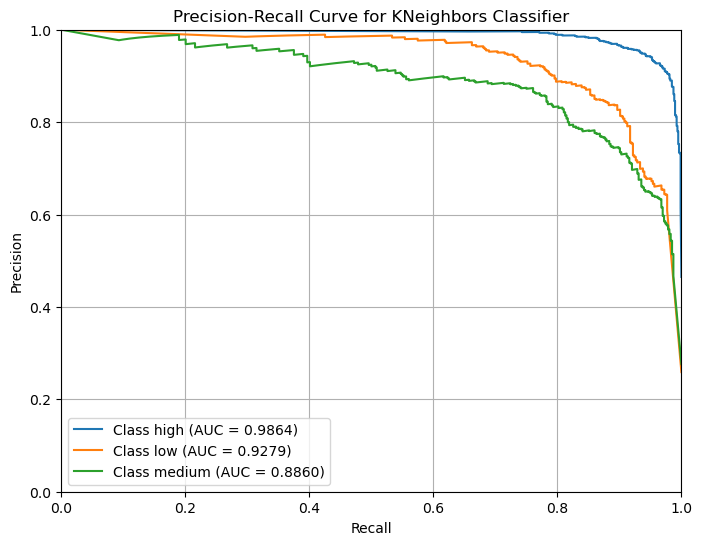

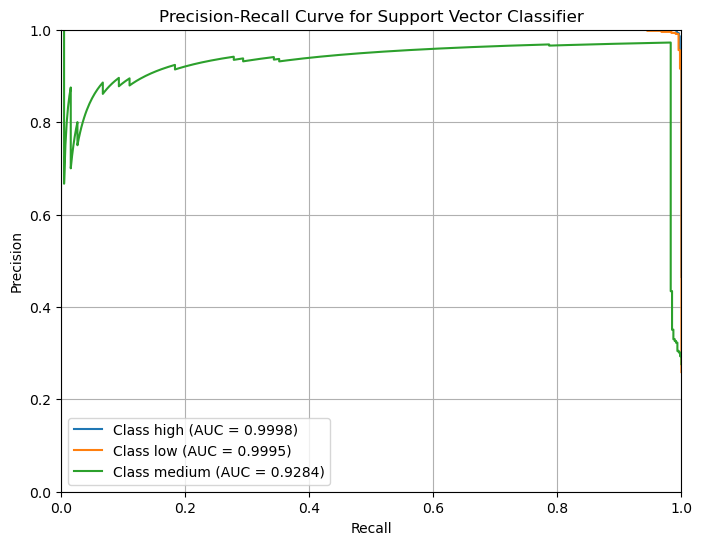

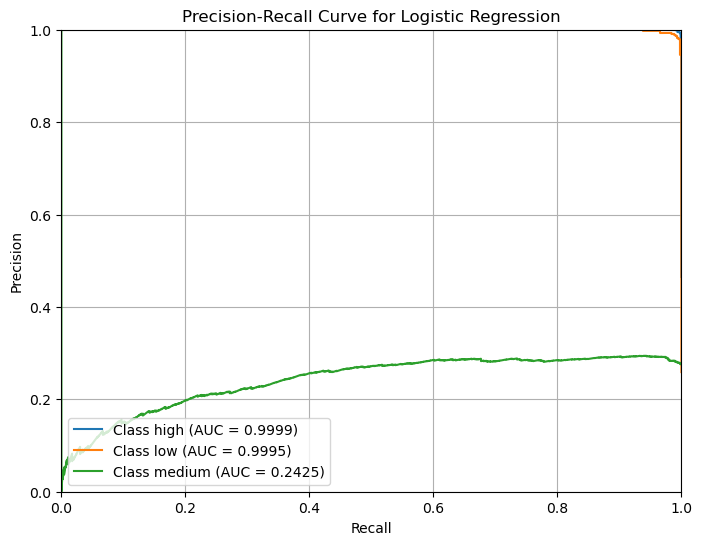

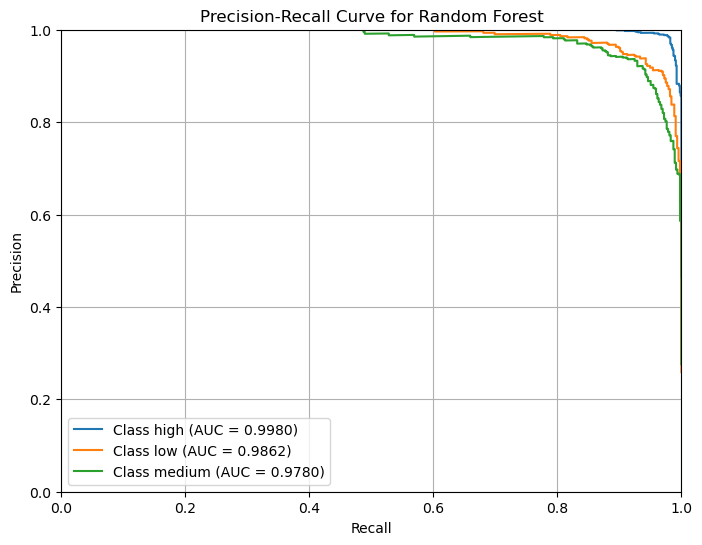

In [135]:
y_scores_best_knn = cross_val_predict(best_model_knn, X_train_tr, y_train, cv=3, method = "predict_proba")
y_scores_best_svc = cross_val_predict(best_model_svc, X_train_tr, y_train, cv=3, method = "decision_function")
y_scores_best_lr = cross_val_predict(best_model_lr, X_train_tr, y_train, cv=3, method = "decision_function")
y_scores_best_rf = cross_val_predict(best_model_rf, X_train_tr, y_train, cv=3, method = "predict_proba")

# Label Classes = [High, Low, Medium]
no_classes = len(class_labels)
# Binarize the output labels for multiclass ROC
y_train_binarized = label_binarize(y_train, classes=class_labels)

models = [
    ('KNeighbors Classifier', y_scores_best_knn),
    ('Support Vector Classifier', y_scores_best_svc),
    ('Logistic Regression', y_scores_best_lr),
    ('Random Forest', y_scores_best_rf)
]

# Create separate plots for each model
for model_name, y_scores in models:
    plt.figure(figsize=(8, 6))
    for i in range(no_classes):
        # Check if the class exists in y_test_binarized
        if np.sum(y_train_binarized[:, i]) > 0:
            # Calculate Precision-Recall curve
            precision, recall, thresholds = precision_recall_curve(y_train_binarized[:, i], y_scores[:, i])
            auc_pr = average_precision_score(y_train_binarized[:, i], y_scores[:, i])
            # Plot the PR curve for each class
            plt.plot(recall, precision, label=f'Class {class_labels[i]} (AUC = {auc_pr:.4f})')
        else:
            print(f"Class {class_labels[i]} is not present in y_test. Skipping PR curve for this class.")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {model_name}')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()


#### 2. Imbalanced Unseen Data

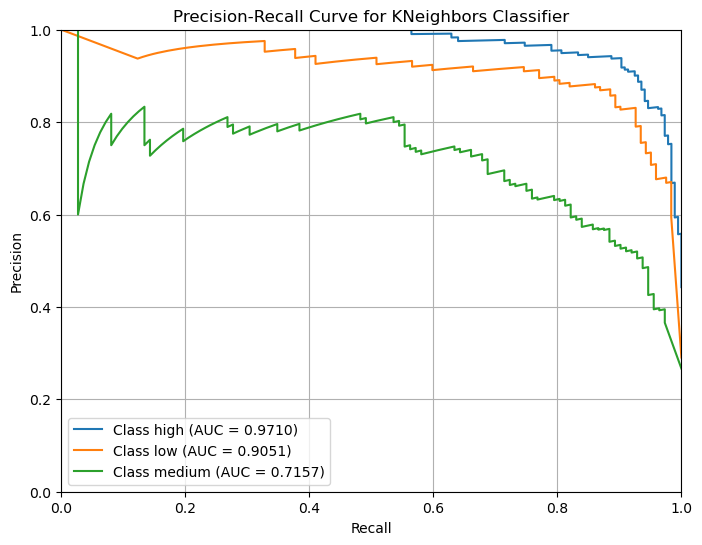

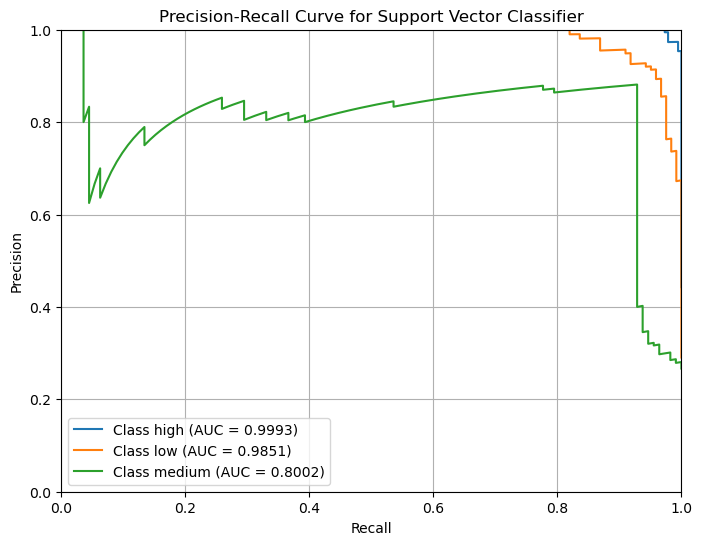

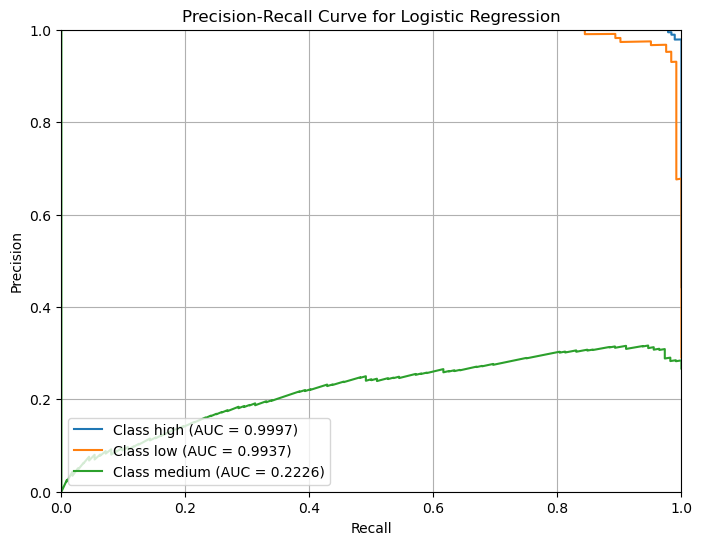

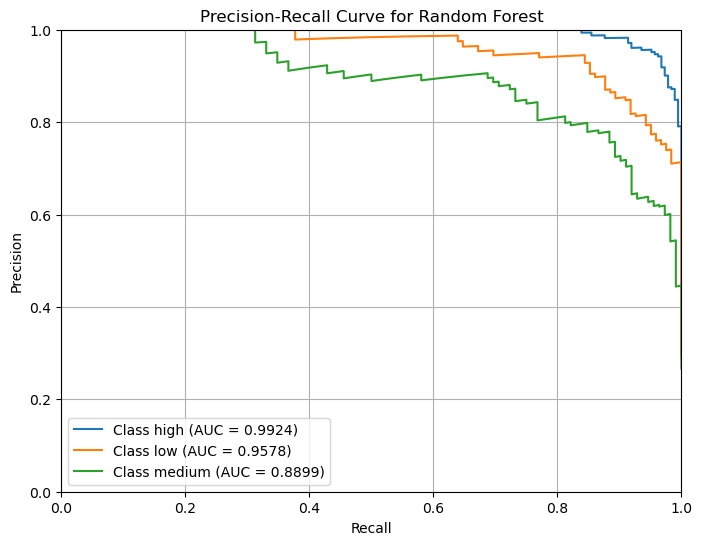

In [136]:
y_scores_best_knn = cross_val_predict(best_model_knn, X_test_tr, y_test, cv=3, method = "predict_proba")
y_scores_best_svc = cross_val_predict(best_model_svc, X_test_tr, y_test, cv=3, method = "decision_function")
y_scores_best_lr = cross_val_predict(best_model_lr, X_test_tr, y_test, cv=3, method = "decision_function")
y_scores_best_rf = cross_val_predict(best_model_rf, X_test_tr, y_test, cv=3, method = "predict_proba")

# Label Classes = [High, Low, Medium]
no_classes = len(class_labels)
# Binarize the output labels for multiclass ROC
y_test_binarized = label_binarize(y_test, classes=class_labels)

models = [
    ('KNeighbors Classifier', y_scores_best_knn),
    ('Support Vector Classifier', y_scores_best_svc),
    ('Logistic Regression', y_scores_best_lr),
    ('Random Forest', y_scores_best_rf)
]

# Create separate plots for each model
for model_name, y_scores in models:
    plt.figure(figsize=(8, 6))
    for i in range(no_classes):
        # Check if the class exists in y_test_binarized
        if np.sum(y_test_binarized[:, i]) > 0:
            # Calculate Precision-Recall curve
            precision, recall, thresholds = precision_recall_curve(y_test_binarized[:, i], y_scores[:, i])
            auc_pr = average_precision_score(y_test_binarized[:, i], y_scores[:, i])
            # Plot the PR curve for each class
            plt.plot(recall, precision, label=f'Class {class_labels[i]} (AUC = {auc_pr:.4f})')
        else:
            print(f"Class {class_labels[i]} is not present in y_test. Skipping PR curve for this class.")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {model_name}')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()


### 3.3 Comparison on ROC Curve using Best Model

#### 1. Imbalanced Trained Dataset

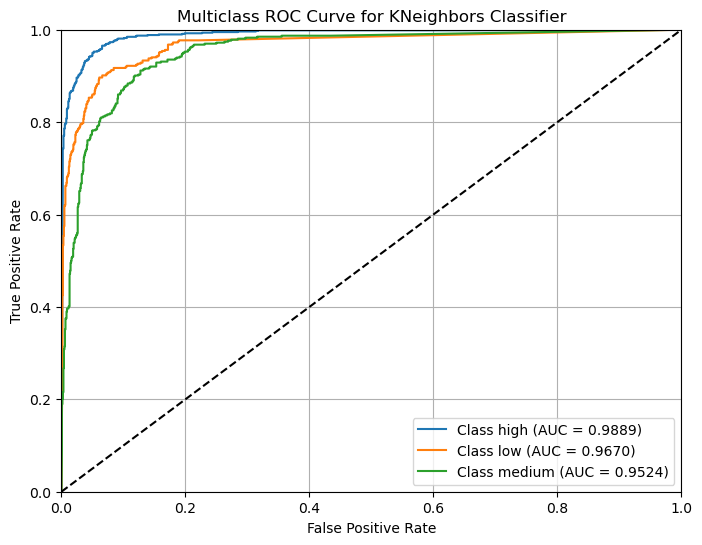

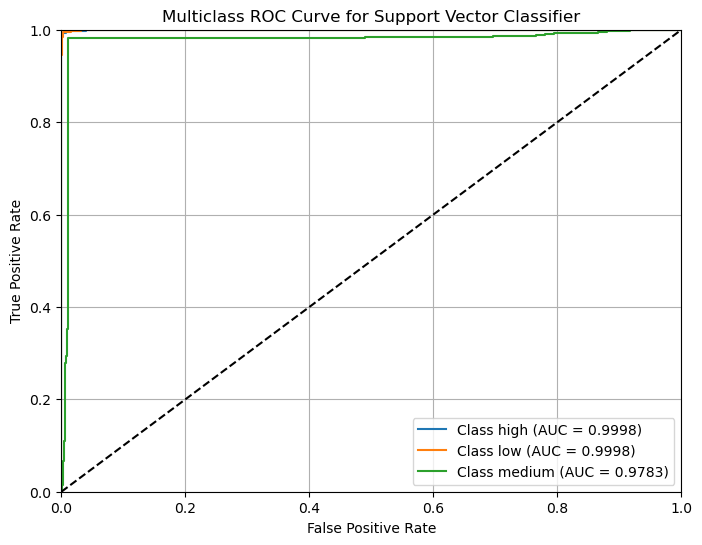

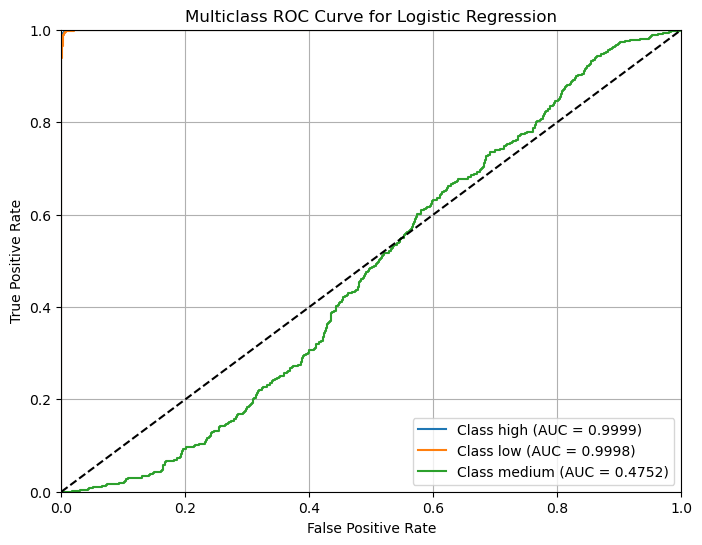

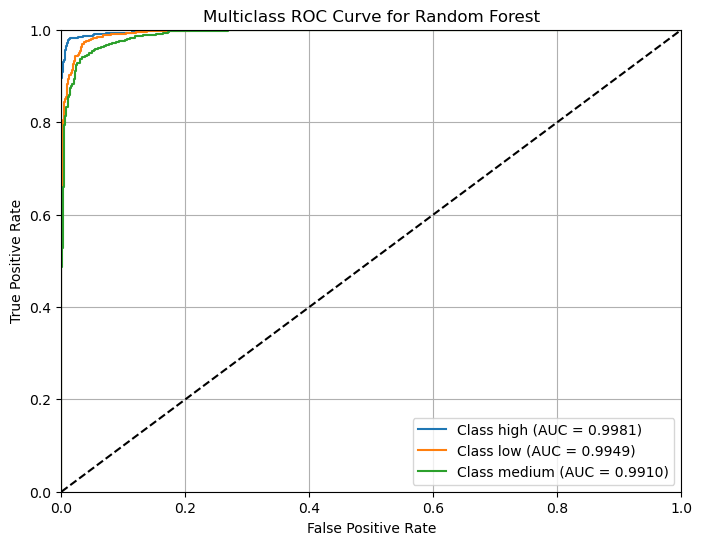

In [137]:
y_scores_best_knn = cross_val_predict(best_model_knn, X_train_tr, y_train, cv=3, method = "predict_proba")
y_scores_best_svc = cross_val_predict(best_model_svc, X_train_tr, y_train, cv=3, method = "decision_function")
y_scores_best_lr = cross_val_predict(best_model_lr, X_train_tr, y_train, cv=3, method = "decision_function")
y_scores_best_rf = cross_val_predict(best_model_rf, X_train_tr, y_train, cv=3, method = "predict_proba")

# Label Classes = [High, Low, Medium]
no_classes = len(class_labels)
# Binarize the output labels for multiclass ROC
y_train_binarized = label_binarize(y_train, classes=class_labels)

models = [
    ('KNeighbors Classifier', y_scores_best_knn),
    ('Support Vector Classifier', y_scores_best_svc),
    ('Logistic Regression', y_scores_best_lr),
    ('Random Forest', y_scores_best_rf)
]

# Create separate plots for each model
for model_name, y_scores in models:
    plt.figure(figsize=(8, 6))
    for i in range(no_classes):
        # Check if the class exists in y_test_binarized
        if np.sum(y_train_binarized[:, i]) > 0:
            fpr, tpr, thresholds = roc_curve(y_train_binarized[:, i], y_scores[:, i])
            auc_score = roc_auc_score(y_train_binarized[:, i], y_scores[:, i])
            plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.4f})')
        else:
            print(f"Class {i} is not present in y_test. Skipping ROC curve for this class.")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multiclass ROC Curve for {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

#### 2. Imbalanced Unseen Data

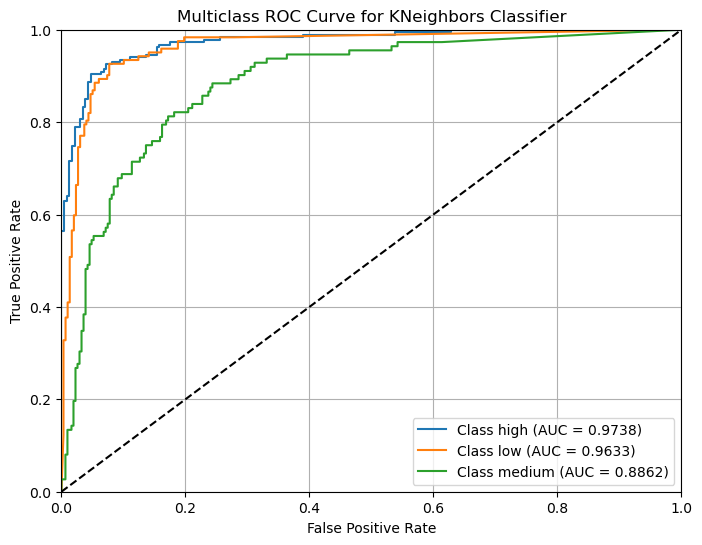

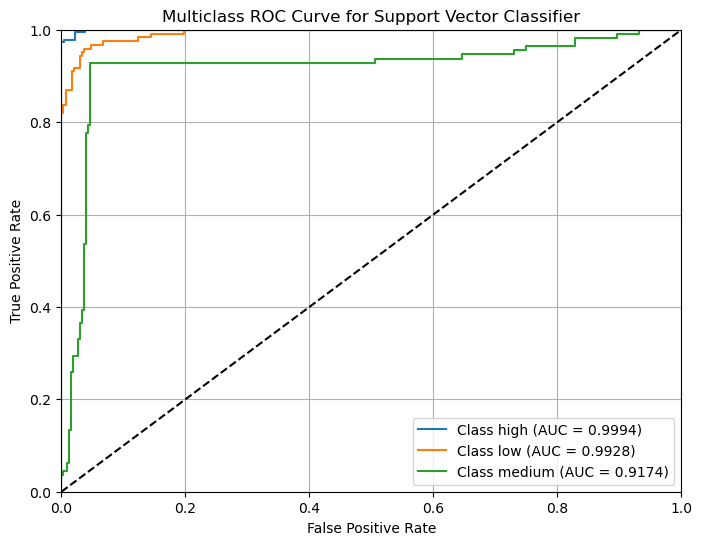

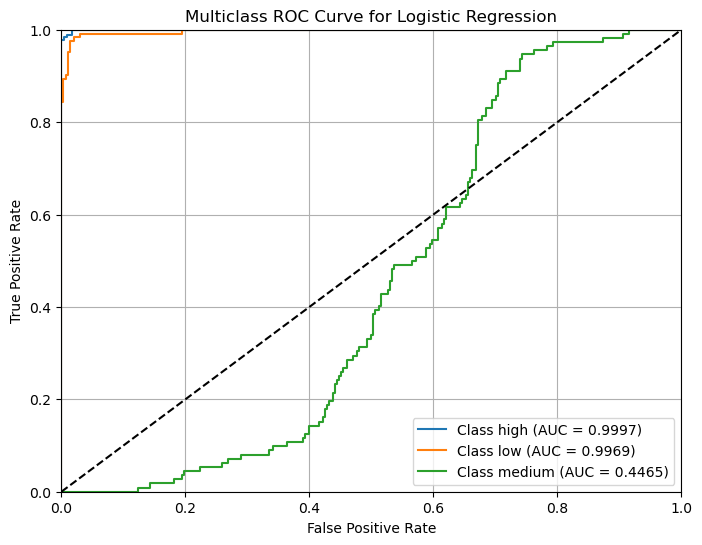

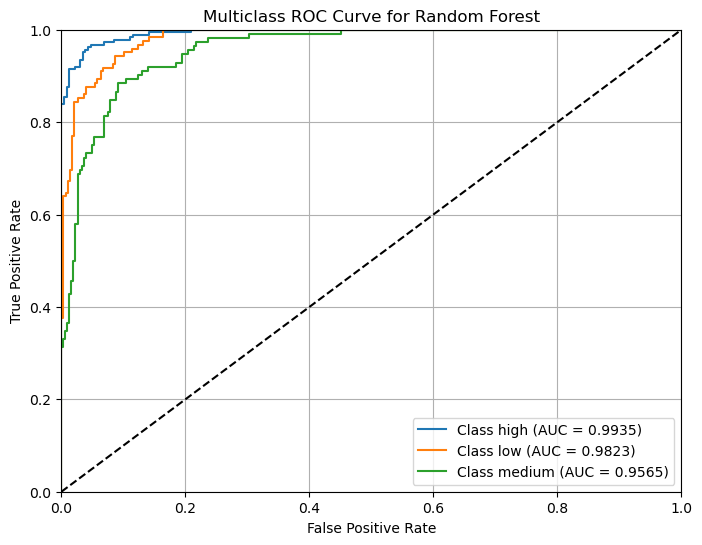

In [138]:
y_scores_best_knn = cross_val_predict(best_model_knn, X_test_tr, y_test, cv=3, method = "predict_proba")
y_scores_best_svc = cross_val_predict(best_model_svc, X_test_tr, y_test, cv=3, method = "decision_function")
y_scores_best_lr = cross_val_predict(best_model_lr, X_test_tr, y_test, cv=3, method = "decision_function")
y_scores_best_rf = cross_val_predict(best_model_rf, X_test_tr, y_test, cv=3, method = "predict_proba")

# Label Classes = [High, Low, Medium]
no_classes = len(class_labels)
# Binarize the output labels for multiclass ROC
y_test_binarized = label_binarize(y_test, classes=class_labels)

models = [
    ('KNeighbors Classifier', y_scores_best_knn),
    ('Support Vector Classifier', y_scores_best_svc),
    ('Logistic Regression', y_scores_best_lr),
    ('Random Forest', y_scores_best_rf)
]

# Create separate plots for each model
for model_name, y_scores in models:
    plt.figure(figsize=(8, 6))
    for i in range(no_classes):
        # Check if the class exists in y_test_binarized
        if np.sum(y_test_binarized[:, i]) > 0:
            fpr, tpr, thresholds = roc_curve(y_test_binarized[:, i], y_scores[:, i])
            auc_score = roc_auc_score(y_test_binarized[:, i], y_scores[:, i])
            plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_score:.4f})')
        else:
            print(f"Class {i} is not present in y_test. Skipping ROC curve for this class.")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multiclass ROC Curve for {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


### 3.4 Comparison on Average PR Curves

#### 1. Imbalanced Trained Dataset

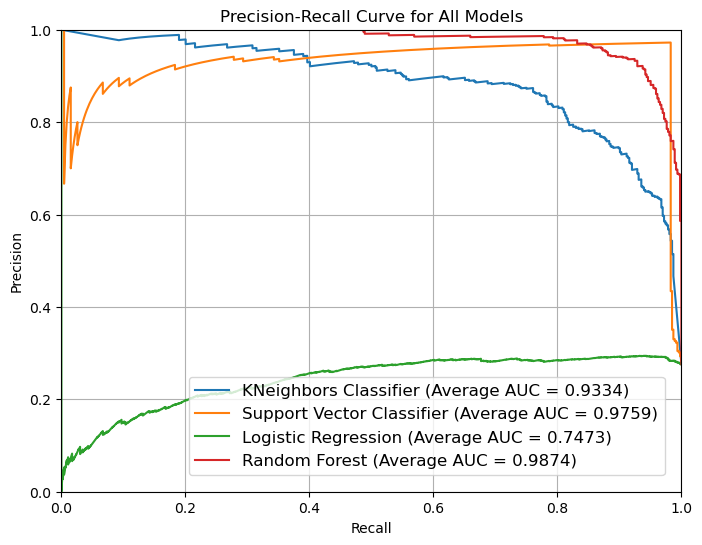

In [139]:
best_model_knn = best_model_knn.fit(X_train_tr, y_train)
best_model_svc = best_model_svc.fit(X_train_tr, y_train)
best_model_lr = best_model_lr.fit(X_train_tr, y_train)
best_model_rf = best_model_rf.fit(X_train_tr, y_train)

y_scores_best_knn = cross_val_predict(best_model_knn, X_train_tr, y_train, cv=3, method = "predict_proba")
y_scores_best_svc = cross_val_predict(best_model_svc, X_train_tr, y_train, cv=3, method = "decision_function")
y_scores_best_lr = cross_val_predict(best_model_lr, X_train_tr, y_train, cv=3, method = "decision_function")
y_scores_best_rf = cross_val_predict(best_model_rf, X_train_tr, y_train, cv=3, method = "predict_proba")

# Assuming y_scores_best_knn, y_scores_best_svc, y_scores_best_lr, y_scores_best_rf are already defined
models = [
    ('KNeighbors Classifier', y_scores_best_knn),
    ('Support Vector Classifier', y_scores_best_svc),
    ('Logistic Regression', y_scores_best_lr),
    ('Random Forest', y_scores_best_rf)
]

# Label Classes = [High, Low, Medium]
no_classes = len(class_labels)
y_train_binarized = label_binarize(y_train, classes=class_labels)

plt.figure(figsize=(8, 6))

for model_name, y_scores in models:
    average_precision = 0
    for i in range(no_classes):
        precision, recall, _ = precision_recall_curve(y_train_binarized[:, i], y_scores[:, i])
        average_precision += average_precision_score(y_train_binarized[:, i], y_scores[:, i])
    
    average_precision /= no_classes
    
    # Plot average PR curve
    plt.plot(recall, precision, label=f'{model_name} (Average AUC = {average_precision:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for All Models')
plt.legend(loc="lower right", fontsize='large', bbox_to_anchor=(1, 0), borderaxespad=1)
plt.grid(True)
plt.show()


#### 2. Balanced Trained Dataset

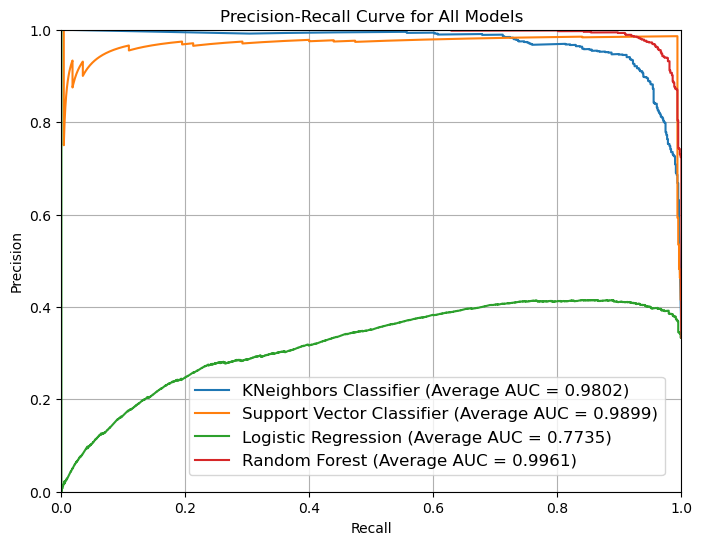

In [140]:
best_model_knn = best_model_knn.fit(X_train_res, y_train_res)
best_model_svc = best_model_svc.fit(X_train_res, y_train_res)
best_model_lr = best_model_lr.fit(X_train_res, y_train_res)
best_model_rf = best_model_rf.fit(X_train_res, y_train_res)

y_scores_best_knn = cross_val_predict(best_model_knn, X_train_res, y_train_res, cv=3, method = "predict_proba")
y_scores_best_svc = cross_val_predict(best_model_svc, X_train_res, y_train_res, cv=3, method = "decision_function")
y_scores_best_lr = cross_val_predict(best_model_lr, X_train_res, y_train_res, cv=3, method = "decision_function")
y_scores_best_rf = cross_val_predict(best_model_rf, X_train_res, y_train_res, cv=3, method = "predict_proba")

# Assuming y_scores_best_knn, y_scores_best_svc, y_scores_best_lr, y_scores_best_rf are already defined
models = [
    ('KNeighbors Classifier', y_scores_best_knn),
    ('Support Vector Classifier', y_scores_best_svc),
    ('Logistic Regression', y_scores_best_lr),
    ('Random Forest', y_scores_best_rf)
]

# Label Classes = [High, Low, Medium]
no_classes = len(class_labels)
y_train_binarized = label_binarize(y_train_res, classes=class_labels)


plt.figure(figsize=(8, 6))

for model_name, y_scores in models:
    average_precision = 0
    for i in range(no_classes):
        precision, recall, _ = precision_recall_curve(y_train_binarized[:, i], y_scores[:, i])
        average_precision += average_precision_score(y_train_binarized[:, i], y_scores[:, i])
        
    average_precision /= no_classes
    
    # Plot average PR curve
    plt.plot(recall, precision, label=f'{model_name} (Average AUC = {average_precision:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for All Models')
plt.legend(loc="lower right", fontsize='large', bbox_to_anchor=(1, 0), borderaxespad=1)
plt.grid(True)
plt.show()


### 3.5 Comparison on Average ROC Curves

#### 1. Imbalanced Trained Dataset

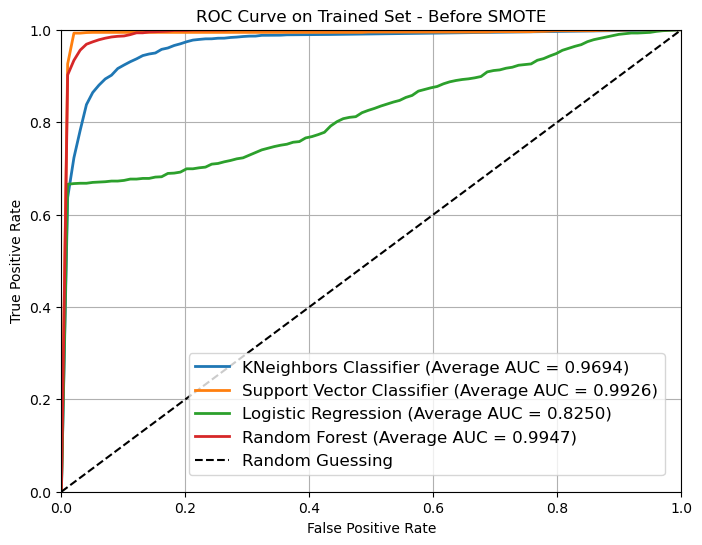

In [141]:
best_model_knn = best_model_knn.fit(X_train_tr, y_train)
best_model_svc = best_model_svc.fit(X_train_tr, y_train)
best_model_lr = best_model_lr.fit(X_train_tr, y_train)
best_model_rf = best_model_rf.fit(X_train_tr, y_train)

y_scores_best_knn = cross_val_predict(best_model_knn, X_train_tr, y_train, cv=3, method = "predict_proba")
y_scores_best_svc = cross_val_predict(best_model_svc, X_train_tr, y_train, cv=3, method = "decision_function")
y_scores_best_lr = cross_val_predict(best_model_lr, X_train_tr, y_train, cv=3, method = "decision_function")
y_scores_best_rf = cross_val_predict(best_model_rf, X_train_tr, y_train, cv=3, method = "predict_proba")

models = [
    ('KNeighbors Classifier', y_scores_best_knn),
    ('Support Vector Classifier', y_scores_best_svc),
    ('Logistic Regression', y_scores_best_lr),
    ('Random Forest', y_scores_best_rf)
]

# Label Classes = [High, Low, Medium]
no_classes = len(class_labels)
y_train_binarized = label_binarize(y_train, classes=class_labels)

plt.figure(figsize=(8, 6))

for model_name, y_scores in models:
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(mean_fpr)
    average_auc = 0
    
    # Calculate ROC curve and AUC for each class
    for i in range(no_classes):
        fpr, tpr, _ = roc_curve(y_train_binarized[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        
        # Interpolate the ROC curve
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        mean_tpr += interp_tpr
        
        average_auc += roc_auc
    
    # Compute average AUC per model
    average_auc /= no_classes
    mean_tpr /= no_classes
    
    # Plot the ROC curve
    plt.plot(mean_fpr, mean_tpr, label=f'{model_name} (Average AUC = {average_auc:.4f})',
             linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Trained Set - Before SMOTE')
plt.legend(loc="lower right", fontsize='large', bbox_to_anchor=(1, 0), borderaxespad=1)
plt.grid(True)
plt.show()


#### 2. Balanced Trained Dataset

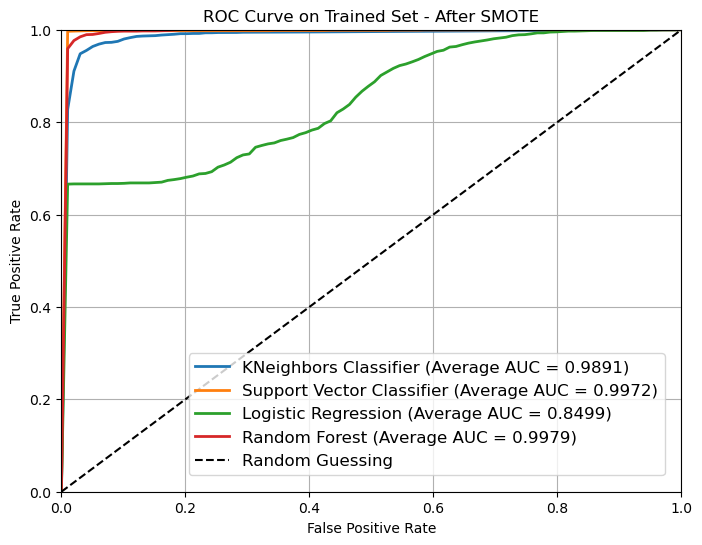

In [142]:
best_model_knn = best_model_knn.fit(X_train_res, y_train_res)
best_model_svc = best_model_svc.fit(X_train_res, y_train_res)
best_model_lr = best_model_lr.fit(X_train_res, y_train_res)
best_model_rf = best_model_rf.fit(X_train_res, y_train_res)

y_scores_best_knn = cross_val_predict(best_model_knn, X_train_res, y_train_res, cv=3, method = "predict_proba")
y_scores_best_svc = cross_val_predict(best_model_svc, X_train_res, y_train_res, cv=3, method = "decision_function")
y_scores_best_lr = cross_val_predict(best_model_lr, X_train_res, y_train_res, cv=3, method = "decision_function")
y_scores_best_rf = cross_val_predict(best_model_rf, X_train_res, y_train_res, cv=3, method = "predict_proba")

models = [
    ('KNeighbors Classifier', y_scores_best_knn),
    ('Support Vector Classifier', y_scores_best_svc),
    ('Logistic Regression', y_scores_best_lr),
    ('Random Forest', y_scores_best_rf)
]

# Label Classes = [High, Low, Medium]
no_classes = len(class_labels)
y_train_binarized = label_binarize(y_train_res, classes=class_labels)

plt.figure(figsize=(8, 6))

for model_name, y_scores in models:
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(mean_fpr)
    average_auc = 0
    
    # Calculate ROC curve and AUC for each class
    for i in range(no_classes):
        fpr, tpr, _ = roc_curve(y_train_binarized[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        
        # Interpolate the ROC curve
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        mean_tpr += interp_tpr
        
        average_auc += roc_auc
    
    # Compute average AUC per model
    average_auc /= no_classes
    mean_tpr /= no_classes
    
    # Plot the ROC curve
    plt.plot(mean_fpr, mean_tpr, label=f'{model_name} (Average AUC = {average_auc:.4f})',
             linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Trained Set - After SMOTE')
plt.legend(loc="lower right", fontsize='large', bbox_to_anchor=(1, 0), borderaxespad=1)
plt.grid(True)
plt.show()


#### 3. Imbalanced Test Data

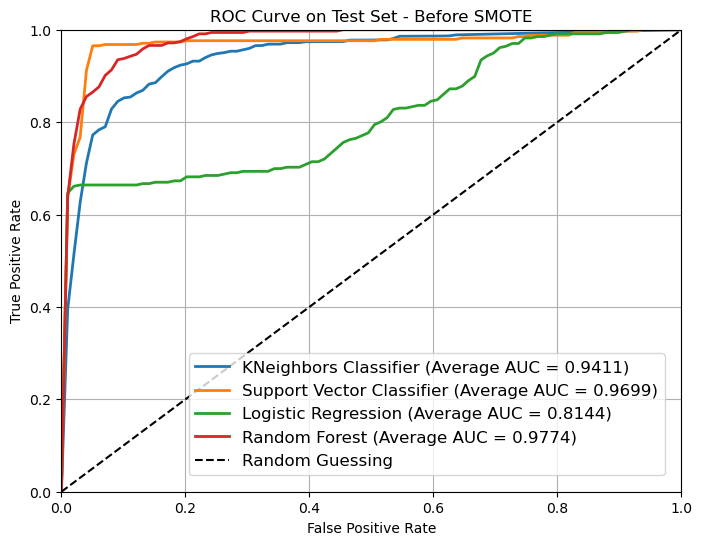

In [143]:
best_model_knn = best_model_knn.fit(X_train_tr, y_train)
best_model_svc = best_model_svc.fit(X_train_tr, y_train)
best_model_lr = best_model_lr.fit(X_train_tr, y_train)
best_model_rf = best_model_rf.fit(X_train_tr, y_train)

y_scores_best_knn = cross_val_predict(best_model_knn, X_test_tr, y_test, cv=3, method = "predict_proba")
y_scores_best_svc = cross_val_predict(best_model_svc, X_test_tr, y_test, cv=3, method = "decision_function")
y_scores_best_lr = cross_val_predict(best_model_lr, X_test_tr, y_test, cv=3, method = "decision_function")
y_scores_best_rf = cross_val_predict(best_model_rf, X_test_tr, y_test, cv=3, method = "predict_proba")

models = [
    ('KNeighbors Classifier', y_scores_best_knn),
    ('Support Vector Classifier', y_scores_best_svc),
    ('Logistic Regression', y_scores_best_lr),
    ('Random Forest', y_scores_best_rf)
]

# Label Classes = [High, Low, Medium]
no_classes = len(class_labels)
y_train_binarized = label_binarize(y_test, classes=class_labels)

plt.figure(figsize=(8, 6))

for model_name, y_scores in models:
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(mean_fpr)
    average_auc = 0
    
    # Calculate ROC curve and AUC for each class
    for i in range(no_classes):
        fpr, tpr, _ = roc_curve(y_train_binarized[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        
        # Interpolate the ROC curve
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        mean_tpr += interp_tpr
        
        average_auc += roc_auc
    
    # Compute average AUC per model
    average_auc /= no_classes
    mean_tpr /= no_classes
    
    # Plot the ROC curve
    plt.plot(mean_fpr, mean_tpr, label=f'{model_name} (Average AUC = {average_auc:.4f})',
             linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set - Before SMOTE')
plt.legend(loc="lower right", fontsize='large', bbox_to_anchor=(1, 0), borderaxespad=1)
plt.grid(True)
plt.show()


#### 4. Balanced Unseen Data

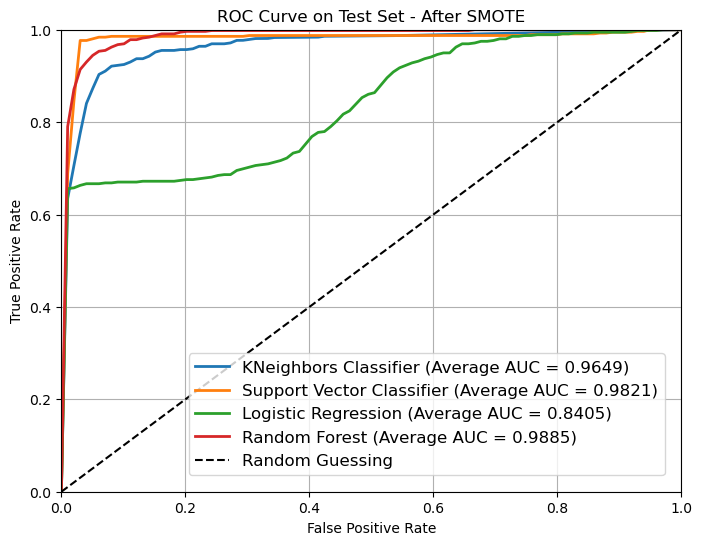

In [144]:
best_model_knn = best_model_knn.fit(X_train_res, y_train_res)
best_model_svc = best_model_svc.fit(X_train_res, y_train_res)
best_model_lr = best_model_lr.fit(X_train_res, y_train_res)
best_model_rf = best_model_rf.fit(X_train_res, y_train_res)

y_scores_best_knn = cross_val_predict(best_model_knn, X_test_res, y_test_res, cv=3, method = "predict_proba")
y_scores_best_svc = cross_val_predict(best_model_svc, X_test_res, y_test_res, cv=3, method = "decision_function")
y_scores_best_lr = cross_val_predict(best_model_lr, X_test_res, y_test_res, cv=3, method = "decision_function")
y_scores_best_rf = cross_val_predict(best_model_rf, X_test_res, y_test_res, cv=3, method = "predict_proba")

models = [
    ('KNeighbors Classifier', y_scores_best_knn),
    ('Support Vector Classifier', y_scores_best_svc),
    ('Logistic Regression', y_scores_best_lr),
    ('Random Forest', y_scores_best_rf)
]

# Label Classes = [High, Low, Medium]
no_classes = len(class_labels)
y_train_binarized = label_binarize(y_test_res, classes=class_labels)

plt.figure(figsize=(8, 6))

for model_name, y_scores in models:
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(mean_fpr)
    average_auc = 0
    
    # Calculate ROC curve and AUC for each class
    for i in range(no_classes):
        fpr, tpr, _ = roc_curve(y_train_binarized[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        
        # Interpolate the ROC curve
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        mean_tpr += interp_tpr
        
        average_auc += roc_auc
    
    # Compute average AUC per model
    average_auc /= no_classes
    mean_tpr /= no_classes
    
    # Plot the ROC curve
    plt.plot(mean_fpr, mean_tpr, label=f'{model_name} (Average AUC = {average_auc:.4f})',
             linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set - After SMOTE')
plt.legend(loc="lower right", fontsize='large', bbox_to_anchor=(1, 0), borderaxespad=1)
plt.grid(True)
plt.show()


### 3.6 Fine-Tune Model using Grid Search

#### We decided to use Random Forest Model as our final model since both precision and recall score are equally higher and have a relatively high f1 score.

1. n_estimators: [20, 40, 60],
2. max_features: [4, 6, 8, 10],
3. max_depth: [4, 6, 8]

In [23]:
# Create a new pipeline
imba_pipeline_forest = make_pipeline(RandomForestClassifier(n_estimators=60, random_state=42))

# Define parameter grid
forest_para = { 
    'randomforestclassifier__n_estimators': [20, 40, 60],
    'randomforestclassifier__max_features': [4, 6, 8, 10],
    'randomforestclassifier__max_depth': [4, 6, 8]
}

# Define the custom scorer for multiclass precision
precision_scorer = make_scorer(precision_score, average='weighted')

# Setup GridSearchCV with the multiclass precision scorer
grid_rf = GridSearchCV(imba_pipeline_forest, param_grid=forest_para, cv=5, scoring=precision_scorer, n_jobs=-1)
grid_rf.fit(X_train_tr, y_train)

# Show the best parameters and score
print('Best Parameter:', grid_rf.best_params_)
print('Best Score:', grid_rf.best_score_)

Best Parameter: {'randomforestclassifier__max_depth': 8, 'randomforestclassifier__max_features': 10, 'randomforestclassifier__n_estimators': 40}
Best Score: 0.9618167830509584


In [24]:
final_model_rf = grid_rf.best_estimator_
print(final_model_rf)

Pipeline(steps=[('randomforestclassifier',
                 RandomForestClassifier(max_depth=8, max_features=10,
                                        n_estimators=40, random_state=42))])


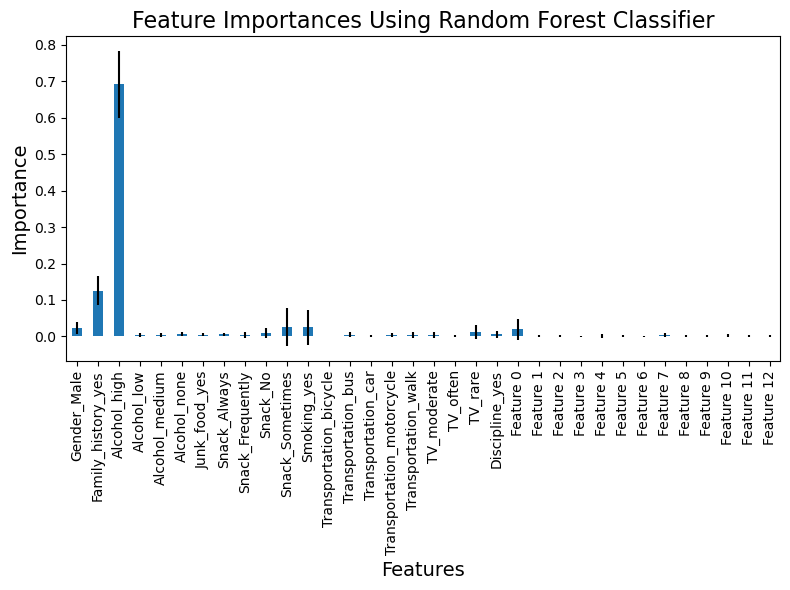

In [191]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example DataFrames and feature names (replace with your actual data and names)
# Assuming X_train_tr and y_train are already defined
# X_train_cat_df_tr and feature_names are from the one-hot encoding step

# Define the final model
final_model = RandomForestClassifier(max_depth=8, max_features=20, n_estimators=60, random_state=42)
final_model.fit(X_train_tr, y_train)

# Get feature importances
importances = final_model.feature_importances_
std = np.std([tree.feature_importances_ for tree in final_model.estimators_], axis=0)

# Combine categorical and numerical feature names
if isinstance(X_train_tr, pd.DataFrame):
    # If X_train_tr is a DataFrame, use its columns
    feature_names = X_train_tr.columns
else:
    # If X_train_tr is not a DataFrame, use X_train_cat_df_tr columns
    feature_names = X_train_cat_df_tr.columns.tolist() + [f'Feature {i}' for i in range(X_train_tr.shape[1] - len(X_train_cat_df_tr.columns))]

# Ensure the feature_names length matches the number of importances
assert len(feature_names) == len(importances), "Mismatch between number of importances and feature names."

# Create a DataFrame for feature importances
forest_importances = pd.Series(importances, index=feature_names)

# Plot feature importances
fig, ax = plt.subplots(figsize=(8, 6))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature Importances Using Random Forest Classifier", fontsize=16)
ax.set_xlabel("Features", fontsize=14)
ax.set_ylabel("Importance", fontsize=14)
fig.tight_layout()
plt.show()


In [192]:
forest_importances.sort_values(inplace=True, ascending=False)
print(forest_importances)

Alcohol_high                 0.691606
Family_history_yes           0.125312
Snack_Sometimes              0.026198
Smoking_yes                  0.024678
Gender_Male                  0.023046
Feature 0                    0.019152
TV_rare                      0.011192
Snack_No                     0.009813
Snack_Always                 0.005734
Alcohol_none                 0.005731
Discipline_yes               0.005341
Transportation_bus           0.004696
Snack_Frequently             0.004669
Junk_food_yes                0.004232
Feature 7                    0.003531
Transportation_walk          0.003224
Transportation_motorcycle    0.003197
Alcohol_medium               0.003169
TV_moderate                  0.003140
Alcohol_low                  0.002896
Feature 10                   0.002212
Feature 4                    0.002130
Feature 2                    0.001793
Feature 12                   0.001765
Feature 1                    0.001693
Feature 11                   0.001639
Transportati